## Matt note

A 7-, 14- or 30-day path is **not** one model rolled forward.

There is a separately tuned Random Forest for every lead h = 1, 2, ..., 30 (best 1-day model, best 2-day model, and so on). Each model predicts only day t+h from features known at origin t.

The pooled-path score **stitches** those specialists: from the same start date, take the 1-day forecast for t+1, the 2-day forecast for t+2, up to t+H. That is direct multi-horizon forecasting. The 1-day model is never fed back to make day 2.

The neural notebooks are different: one multi-output network per H, trained on the whole path at once.


> **Copy note.** This notebook is a copy of `Random_Forest.ipynb`. The code now trains a direct model for every lead 1…30 and reports pooled-path test metrics at 7, 14 and 30 days so they can be compared with the neural notebooks. The markdown below is still the original four-horizon write-up and will need editing. Stale cells have a note at the bottom. Code edits are marked with `# Changed:`.

> **Matt note.** A 7-, 14- or 30-day path is **not** one model rolled forward. There is a separately tuned Random Forest for every lead h = 1, 2, ..., 30 (best 1-day model, best 2-day model, ...). Each model predicts only day t+h from features known at origin t. The pooled-path score **stitches** those specialists: from the same start date, take the 1-day forecast for t+1, the 2-day forecast for t+2, ..., up to t+H. That is *direct* multi-horizon forecasting. The 1-day model is never fed back to make day 2. The neural notebooks are different: one multi-output network per H, trained on the whole path at once.

# Random Forest Multi-Horizon Forecasting of Daily PM 2.5
## London Marylebone Road

### Research objective

This notebook implements a **direct multi-horizon Random Forest regression framework** for forecasting daily PM$_{2.5}$ concentrations at lead times of **1, 7, 14, and 30 days**. The central modelling question is whether a non-linear ensemble of decision trees can retain useful predictive skill as the forecast horizon increases, while remaining interpretable and robust under a strictly chronological evaluation design.

For each horizon $h \in \{1,7,14,30\}$, a separate model is estimated:

$$
\hat{y}_{t+h}=f_h(\mathbf{x}_t),
$$

where $\mathbf{x}_t$ denotes the predictor vector available at forecast origin $t$, and $y_{t+h}$ is the observed PM$_{2.5}$ concentration $h$ days later.

The analysis emphasises four principles: **temporal integrity**, **out-of-sample evaluation**, **comparison with a persistence benchmark**, and **post-hoc model interpretability**.

---

> **Needs rewrite.** This markdown still describes the original setup (direct models only at 1, 7, 14 and 30 days; the score is day *h* only). After the code change: a direct model is trained for every lead 1…30. The numbers that match CNN-LSTM / transformer / LSTM / GRU are **pooled over the full path** `[y_{t+1}, …, y_{t+H}]` for *H* in {7, 14, 30}, using test origins that have every lead of that path.


In [40]:
# ============================================================
# RANDOM FOREST – MULTI-HORIZON PM2.5 FORECASTING
# London Marylebone Road
#
# Direct forecast horizons:
# 1 day, 7 days, 14 days and 30 days ahead
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

from pathlib import Path
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")


## Experimental configuration and reproducibility

The experiment is configured once and then reused consistently across all forecast horizons. A fixed random seed is specified to make stochastic components of model fitting and hyperparameter search reproducible. Model artefacts, prediction files, and evaluation outputs are written to dedicated directories so that the complete forecasting workflow can be audited and reproduced.

The target variable is daily PM$_{2.5}$. The date field and contemporaneous target are excluded from the predictor matrix itself, while engineered temporal, lagged-pollution, and meteorological variables remain available as candidate predictors.

---

> **Needs rewrite.** This markdown still describes the original setup (direct models only at 1, 7, 14 and 30 days; the score is day *h* only). After the code change: a direct model is trained for every lead 1…30. The numbers that match CNN-LSTM / transformer / LSTM / GRU are **pooled over the full path** `[y_{t+1}, …, y_{t+H}]` for *H* in {7, 14, 30}, using test origins that have every lead of that path.


In [41]:

# ============================================================
# 2. CONFIGURATION
# ============================================================

# Dataset folder — repo data/modelling (run this notebook from notebooks/models/)
DATA_DIR = Path("../../data/modelling")

# Target variable
TARGET = "pm25"

# Columns excluded from model predictors
DROP_COLS = ["date", TARGET]

# Folder for saved Random Forest models
MODEL_DIR = Path("saved_con_rf")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Folder for results, predictions and figures
RESULTS_DIR = Path("rf_results_path")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Changed: direct model for every lead 1..30 (was [1, 7, 14, 30]).
FORECAST_HORIZONS = list(range(1, 31))
# Changed: pooled-path lengths that match the neural notebooks.
PATH_HORIZONS = [7, 14, 30]

# Reproducibility
RANDOM_STATE = 42


In [42]:

# ============================================================
# 3. DATASET PATHS
# ============================================================

TRAIN_PATH = DATA_DIR / "marylebone_train.csv"
TEST_PATH = DATA_DIR / "marylebone_test.csv"
ALL_PATH = DATA_DIR / "marylebone_all.csv"

print("Current directory :", Path.cwd())
print("Dataset directory :", DATA_DIR.resolve())
print("Model directory   :", MODEL_DIR.resolve())
print("Results directory :", RESULTS_DIR.resolve())

Current directory : /Users/matthewbutler/Documents/MastersPaper/code/model_training
Dataset directory : /Users/matthewbutler/Documents/MastersPaper/code/data/splits
Model directory   : /Users/matthewbutler/Documents/MastersPaper/code/model_training/saved_con_rf
Results directory : /Users/matthewbutler/Documents/MastersPaper/code/model_training/rf_results_path


In [43]:
# ============================================================
# 4. CHECK FILES
# ============================================================

required_files = [
    TRAIN_PATH,
    TEST_PATH,
    ALL_PATH
]

for file_path in required_files:

    if not file_path.exists():

        raise FileNotFoundError(
            f"File not found: {file_path}\n"
            "Check the exact CSV filename inside "
            "data/modelling."
        )

print("\nAll required dataset files were found.")


All required dataset files were found.


## Data ingestion and temporal partitioning

The modelling pipeline uses pre-defined training, test, and complete datasets. Dates are parsed explicitly, observations are sorted chronologically, and the train/test boundaries are derived from the data rather than assumed manually.

This chronological separation is essential for time-series forecasting: the holdout period represents genuinely unseen future observations and must not influence model fitting, hyperparameter selection, or feature engineering decisions that would be unavailable at the forecast origin.


In [44]:
# ============================================================
# 5. LOAD DATASETS
# ============================================================

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
df = pd.read_csv(ALL_PATH)

print("\nDataset dimensions")
print("-" * 50)
print("Training :", train_df.shape)
print("Testing  :", test_df.shape)
print("Complete :", df.shape)

display(train_df.head())


Dataset dimensions
--------------------------------------------------
Training : (1000, 42)
Testing  : (364, 42)
Complete : (1364, 42)


,date,year,month,day_of_month,day_of_week_x,day_of_year,week_of_year,quarter,is_weekend,is_weekday,...,air_pressure_max_hpa,air_pressure_min_hpa,temperature_max_c,temperature_min_c,temperature_avg_c,mean_wind_speed_knots,wind_speed_max_knots,wind_speed_min_knots,wind_direction_deg,pm25
0,2022-04-07,2022,4,7,3,97,14,2,0,1,...,1000.9,983.9,13.59414,6.81972,10.206930,13.000000,16.0,4.0,270.636089,5.53
1,2022-04-08,2022,4,8,4,98,14,2,0,1,...,1008.6,997.8,11.35049,1.85771,6.604100,4.291667,9.0,1.0,16.779591,6.72
2,2022-04-09,2022,4,9,5,99,14,2,1,0,...,1019.1,1009.7,12.38106,0.59361,6.487335,5.458333,9.0,3.0,306.186614,5.62
3,2022-04-10,2022,4,10,6,100,14,2,1,0,...,1020.3,1016.2,13.33323,-0.20325,6.564990,2.916667,5.0,1.0,160.738319,8.36
4,2022-04-11,2022,4,11,0,101,15,2,0,1,...,1015.9,1005.9,17.46319,5.01811,11.240650,3.500000,7.0,1.0,119.167789,15.90


In [45]:
# ============================================================
# 6. DATE PREPARATION
# ============================================================

for dataset in [train_df, test_df, df]:

    dataset["date"] = pd.to_datetime(
        dataset["date"],
        errors="raise"
    )

    dataset.sort_values(
        "date",
        inplace=True
    )

    dataset.reset_index(
        drop=True,
        inplace=True
    )


print("\nTraining period:")
print(
    train_df["date"].min(),
    "to",
    train_df["date"].max()
)

print("\nTesting period:")
print(
    test_df["date"].min(),
    "to",
    test_df["date"].max()
)


Training period:
2022-04-07 00:00:00 to 2024-12-31 00:00:00

Testing period:
2025-01-01 00:00:00 to 2025-12-30 00:00:00


In [46]:
# ============================================================
# 7. TRAIN / TEST BOUNDARIES
# ============================================================

TRAIN_END = train_df["date"].max()
TEST_START = test_df["date"].min()
TEST_END = test_df["date"].max()

print("\nChronological boundaries")
print("-" * 50)
print("Training ends :", TRAIN_END)
print("Testing starts:", TEST_START)
print("Testing ends  :", TEST_END)


Chronological boundaries
--------------------------------------------------
Training ends : 2024-12-31 00:00:00
Testing starts: 2025-01-01 00:00:00
Testing ends  : 2025-12-30 00:00:00


## Data quality and temporal integrity checks

Before modelling, the notebook performs structural checks on the daily time series. Missing values, duplicate dates, and discontinuities in the daily sequence are inspected because each can alter the meaning of lagged predictors and future-shifted targets.

A forecasting dataset should preserve the temporal relationship between $t$ and $t+h$. Duplicate timestamps or unrecognised gaps can break that relationship and may therefore introduce misaligned targets or misleading estimates of predictive performance. These checks are treated as part of the experimental validity procedure rather than as optional exploratory diagnostics.

---

> **Needs rewrite.** This markdown still describes the original setup (direct models only at 1, 7, 14 and 30 days; the score is day *h* only). After the code change: a direct model is trained for every lead 1…30. The numbers that match CNN-LSTM / transformer / LSTM / GRU are **pooled over the full path** `[y_{t+1}, …, y_{t+H}]` for *H* in {7, 14, 30}, using test origins that have every lead of that path.


In [47]:
# ============================================================
# 8. DATA QUALITY CHECKS
# ============================================================

print("\nData quality checks")
print("-" * 50)

print(
    "Total missing values:",
    df.isna().sum().sum()
)

print(
    "Duplicate dates:",
    df["date"].duplicated().sum()
)

print("\nPM2.5 summary:")
display(df[TARGET].describe())


if df["date"].duplicated().any():

    raise ValueError(
        "Duplicate dates were detected. "
        "Resolve duplicate observations before modelling."
    )


Data quality checks
--------------------------------------------------
Total missing values: 0
Duplicate dates: 0

PM2.5 summary:


count    1364.000000
mean        8.678425
std         5.663031
min         1.800000
25%         5.400000
50%         6.895000
75%         9.662500
max        59.800000
Name: pm25, dtype: float64

In [48]:

# ============================================================
# 9. CHECK TIME-SERIES CONTINUITY
# ============================================================

date_differences = (
    df["date"]
    .sort_values()
    .diff()
    .dropna()
)

non_daily_gaps = date_differences[
    date_differences != pd.Timedelta(days=1)
]

print(
    "\nNumber of non-daily gaps:",
    len(non_daily_gaps)
)

if len(non_daily_gaps) > 0:

    print(
        "WARNING: The dataset contains non-daily gaps."
    )



Number of non-daily gaps: 0


## Predictor representation

The predictor set combines multiple information sources, including calendar structure, cyclical temporal encodings, recent PM$_{2.5}$ behaviour, and meteorological conditions. All model inputs are verified to be numeric before estimation.

Random Forest does not require feature standardisation because tree splits depend on ordered thresholds rather than Euclidean distance. This allows variables measured on different physical scales to be modelled directly. Nevertheless, redundant or highly correlated predictors can distribute importance across related variables; consequently, feature-importance values are interpreted as model-dependent evidence rather than causal effects.

---

> **Needs rewrite.** This markdown still describes the original setup (direct models only at 1, 7, 14 and 30 days; the score is day *h* only). After the code change: a direct model is trained for every lead 1…30. The numbers that match CNN-LSTM / transformer / LSTM / GRU are **pooled over the full path** `[y_{t+1}, …, y_{t+H}]` for *H* in {7, 14, 30}, using test origins that have every lead of that path.


In [49]:
# ============================================================
# 10. DEFINE FEATURES
# ============================================================

# Remove date and target.
features = [
    column
    for column in df.columns
    if column not in DROP_COLS
]

print("\nNumber of predictor variables:", len(features))

print("\nPredictors:")

for feature in features:
    print(feature)


Number of predictor variables: 40

Predictors:
year
month
day_of_month
day_of_week_x
day_of_year
week_of_year
quarter
is_weekend
is_weekday
season_code
month_sin
month_cos
doy_sin
doy_cos
dow_sin
dow_cos
week_sin
week_cos
pm25_lag1
pm25_lag7
pm25_rollmean3
pm25_rollstd3
day_of_week_y
quarter_num
mean_relative_humidity_pct
relative_humidity_max_pct
relative_humidity_min_pct
total_precipitation_mm
precipitation_max_mm
precipitation_min_mm
mean_air_pressure_hpa
air_pressure_max_hpa
air_pressure_min_hpa
temperature_max_c
temperature_min_c
temperature_avg_c
mean_wind_speed_knots
wind_speed_max_knots
wind_speed_min_knots
wind_direction_deg


In [50]:
# ============================================================
# 11. CHECK THAT ALL PREDICTORS ARE NUMERIC
# ============================================================

non_numeric_features = (
    df[features]
    .select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

if non_numeric_features:

    raise ValueError(
        "The following predictors are non-numeric: "
        f"{non_numeric_features}"
    )

print("\nAll predictors are numeric.")


All predictors are numeric.


## Random Forest specification and hyperparameter optimisation

Random Forest regression combines predictions from many decorrelated decision trees. The ensemble can represent non-linear relationships and higher-order interactions without requiring an explicit parametric functional form. This is appropriate for atmospheric data, where pollutant concentrations may respond non-linearly to recent pollution levels, wind, temperature, pressure, humidity, precipitation, and seasonal structure.

The hyperparameter search explores tree count, maximum depth, minimum split size, minimum leaf size, and the number of predictors considered at each split. Hyperparameters are selected using **RandomizedSearchCV** with **negative MAE** as the optimisation criterion. Random search provides broader coverage of the candidate space than a small manual search while remaining computationally tractable.


In [51]:
# ============================================================
# 12. RANDOM FOREST HYPERPARAMETER SEARCH SPACE
# ============================================================

PARAMETER_GRID = {

    "n_estimators": [
        200,
        300,
        500,
        700
    ],

    "max_depth": [
        None,
        8,
        12,
        16,
        20
    ],

    "min_samples_split": [
        2,
        5,
        10
    ],

    "min_samples_leaf": [
        1,
        2,
        4
    ],

    "max_features": [
        "sqrt",
        0.5,
        0.8
    ],

    "bootstrap": [
        True
    ]
}


In [52]:
# ============================================================
# 13. STORAGE
# ============================================================

results = []

best_models = {}

prediction_data = {}

mdi_importance_data = {}

permutation_importance_data = {}

In [53]:
# ============================================================
# 14. TRAIN RANDOM FOREST FOR EACH FORECAST HORIZON
# Changed: FORECAST_HORIZONS is now 1..30 so a path [t+1, ..., t+H]
# can be assembled. Each model is still a direct day-h forecast.
# Pooled-path scores are computed after this loop.
# ============================================================

for horizon in FORECAST_HORIZONS:

    print("\n")
    print("=" * 75)
    print(
        f"RANDOM FOREST – {horizon}-DAY-AHEAD FORECAST"
    )
    print("=" * 75)


    # ========================================================
    # 14.1 CREATE FUTURE TARGET
    # ========================================================

    data = df.copy()

    target_column = (
        f"target_pm25_{horizon}d"
    )

    target_date_column = (
        f"target_date_{horizon}d"
    )


    # Features at time t predict PM2.5 at t + horizon
    data[target_column] = (
        data[TARGET]
        .shift(-horizon)
    )

    data[target_date_column] = (
        data["date"]
        .shift(-horizon)
    )


    # ========================================================
    # 14.2 REMOVE ROWS WITHOUT FUTURE TARGETS
    # ========================================================

    data = data.dropna(
        subset=[
            target_column,
            target_date_column
        ]
    ).copy()


    # ========================================================
    # 14.3 CREATE TRAINING SET
    # ========================================================
    #
    # The forecast origin and forecast target must both
    # remain inside the original training period.
    #
    # This prevents 2025 target values from entering training.
    # ========================================================

    train_data = data[
        (data["date"] <= TRAIN_END)
        &
        (data[target_date_column] <= TRAIN_END)
    ].copy()


    # ========================================================
    # 14.4 CREATE TEST SET
    # ========================================================

    test_data = data[
        (data["date"] >= TEST_START)
        &
        (data["date"] <= TEST_END)
        &
        (data[target_date_column] <= TEST_END)
    ].copy()


    print(
        "Training observations:",
        len(train_data)
    )

    print(
        "Testing observations :",
        len(test_data)
    )


    # ========================================================
    # 14.5 PREPARE X AND y
    # ========================================================

    X_train = train_data[
        features
    ].copy()

    y_train = train_data[
        target_column
    ].copy()

    X_test = test_data[
        features
    ].copy()

    y_test = test_data[
        target_column
    ].copy()


    # ========================================================
    # 14.6 SAFETY CHECKS
    # ========================================================

    if X_train.isna().any().any():

        raise ValueError(
            f"Missing predictor values found "
            f"in {horizon}-day training data."
        )

    if X_test.isna().any().any():

        raise ValueError(
            f"Missing predictor values found "
            f"in {horizon}-day testing data."
        )


    # ========================================================
    # 14.7 HORIZON-AWARE TIME-SERIES CROSS-VALIDATION
    # ========================================================
    #
    # The gap separates the end of each training fold
    # from its validation fold.
    #
    # ========================================================

    tscv = TimeSeriesSplit(
        n_splits=5,
        gap=horizon
    )


    # ========================================================
    # 14.8 INITIAL RANDOM FOREST
    # ========================================================

    rf = RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    )


    # ========================================================
    # 14.9 HYPERPARAMETER TUNING
    # ========================================================

    search = RandomizedSearchCV(

        estimator=rf,

        param_distributions=PARAMETER_GRID,

        n_iter=30,

        scoring="neg_mean_absolute_error",

        cv=tscv,

        random_state=RANDOM_STATE,

        n_jobs=-1,

        verbose=1,

        refit=True
    )


    print("\nHyperparameter optimisation started...")


    search.fit(
        X_train,
        y_train
    )


    # Best model
    best_rf = search.best_estimator_

    best_models[horizon] = best_rf


    # Best cross-validation MAE
    best_cv_mae = -search.best_score_


    print("\nBest hyperparameters:")

    for parameter, value in search.best_params_.items():

        print(
            f"{parameter}: {value}"
        )


    print(
        f"\nBest CV MAE: {best_cv_mae:.4f}"
    )


    # ========================================================
    # 14.10 TEST-SET PREDICTIONS
    # ========================================================

    y_pred = best_rf.predict(
        X_test
    )


    # ========================================================
    # 14.11 RANDOM FOREST PERFORMANCE
    # ========================================================

    y_true = y_test.to_numpy()


    # Mean Absolute Error
    rf_mae = mean_absolute_error(
        y_true,
        y_pred
    )


    # Mean Squared Error
    rf_mse = mean_squared_error(
        y_true,
        y_pred
    )


    # Root Mean Squared Error
    rf_rmse = np.sqrt(
        rf_mse
    )


    # R-squared
    rf_r2 = r2_score(
        y_true,
        y_pred
    )


    # Mean Absolute Percentage Error
    rf_mape = (
        np.mean(
            np.abs(
                (y_true - y_pred)
                /
                np.maximum(
                    np.abs(y_true),
                    1e-8
                )
            )
        )
        * 100
    )


    # Mean Bias Error
    # Positive = overprediction
    # Negative = underprediction
    rf_mbe = np.mean(
        y_pred - y_true
    )


    # ========================================================
    # 14.12 PERSISTENCE BASELINE
    # ========================================================
    #
    # Baseline:
    #
    # PM2.5(t+h) = PM2.5(t)
    #
    # ========================================================

    persistence_pred = (
        test_data[TARGET]
        .to_numpy()
    )


    baseline_mae = mean_absolute_error(
        y_true,
        persistence_pred
    )


    baseline_mse = mean_squared_error(
        y_true,
        persistence_pred
    )


    baseline_rmse = np.sqrt(
        baseline_mse
    )


    baseline_r2 = r2_score(
        y_true,
        persistence_pred
    )


    baseline_mape = (
        np.mean(
            np.abs(
                (y_true - persistence_pred)
                /
                np.maximum(
                    np.abs(y_true),
                    1e-8
                )
            )
        )
        * 100
    )


    baseline_mbe = np.mean(
        persistence_pred - y_true
    )


    # ========================================================
    # 14.13 IMPROVEMENT OVER BASELINE
    # ========================================================

    mae_improvement_pct = (
        (
            baseline_mae - rf_mae
        )
        /
        baseline_mae
        * 100
    )


    rmse_improvement_pct = (
        (
            baseline_rmse - rf_rmse
        )
        /
        baseline_rmse
        * 100
    )


    # ========================================================
    # 14.14 PRINT PERFORMANCE
    # ========================================================

    print("\nRandom Forest performance")
    print("-" * 45)

    print(
        f"MAE : {rf_mae:.4f}"
    )

    print(
        f"MSE : {rf_mse:.4f}"
    )

    print(
        f"RMSE: {rf_rmse:.4f}"
    )

    print(
        f"R²  : {rf_r2:.4f}"
    )

    print(
        f"MAPE: {rf_mape:.2f}%"
    )

    print(
        f"MBE : {rf_mbe:.4f}"
    )


    print("\nPersistence baseline")
    print("-" * 45)

    print(
        f"MAE : {baseline_mae:.4f}"
    )

    print(
        f"MSE : {baseline_mse:.4f}"
    )

    print(
        f"RMSE: {baseline_rmse:.4f}"
    )

    print(
        f"R²  : {baseline_r2:.4f}"
    )

    print(
        f"MAPE: {baseline_mape:.2f}%"
    )

    print(
        f"MBE : {baseline_mbe:.4f}"
    )


    print("\nImprovement over persistence")
    print("-" * 45)

    print(
        f"MAE improvement : "
        f"{mae_improvement_pct:.2f}%"
    )

    print(
        f"RMSE improvement: "
        f"{rmse_improvement_pct:.2f}%"
    )


    # ========================================================
    # 14.15 STORE PERFORMANCE
    # ========================================================

    results.append({

        "Horizon_Days":
            horizon,

        "Model":
            "Random Forest",

        "Training_Observations":
            len(train_data),

        "Testing_Observations":
            len(test_data),

        "CV_MAE":
            best_cv_mae,

        "MAE":
            rf_mae,

        "MSE":
            rf_mse,

        "RMSE":
            rf_rmse,

        "R2":
            rf_r2,

        "MAPE":
            rf_mape,

        "MBE":
            rf_mbe,

        "Persistence_MAE":
            baseline_mae,

        "Persistence_MSE":
            baseline_mse,

        "Persistence_RMSE":
            baseline_rmse,

        "Persistence_R2":
            baseline_r2,

        "Persistence_MAPE":
            baseline_mape,

        "Persistence_MBE":
            baseline_mbe,

        "MAE_Improvement_Percent":
            mae_improvement_pct,

        "RMSE_Improvement_Percent":
            rmse_improvement_pct
    })


    # ========================================================
    # 14.16 CREATE PREDICTION DATAFRAME
    # ========================================================

    prediction_df = pd.DataFrame({

        "Forecast_Origin":
            test_data[
                "date"
            ].to_numpy(),

        "Target_Date":
            test_data[
                target_date_column
            ].to_numpy(),

        "Actual_PM25":
            y_true,

        "Predicted_PM25":
            y_pred,

        "Persistence_PM25":
            persistence_pred,

        "Residual":
            (
                y_true
                -
                y_pred
            )
    })


    prediction_data[horizon] = prediction_df


    # Save predictions
    prediction_df.to_csv(

        RESULTS_DIR
        /
        f"rf_predictions_{horizon}d.csv",

        index=False
    )


    # ========================================================
    # 14.17 STANDARD RANDOM FOREST FEATURE IMPORTANCE
    # ========================================================

    mdi_df = pd.DataFrame({

        "Feature":
            features,

        "Importance":
            best_rf.feature_importances_

    }).sort_values(

        "Importance",
        ascending=False

    ).reset_index(
        drop=True
    )


    mdi_importance_data[horizon] = mdi_df


    mdi_df.to_csv(

        RESULTS_DIR
        /
        f"rf_feature_importance_{horizon}d.csv",

        index=False
    )


    # ========================================================
    # 14.18 PERMUTATION IMPORTANCE
    # ========================================================

    perm_result = permutation_importance(

        best_rf,

        X_test,

        y_test,

        scoring="neg_mean_absolute_error",

        n_repeats=20,

        random_state=RANDOM_STATE,

        n_jobs=-1
    )


    permutation_df = pd.DataFrame({

        "Feature":
            features,

        "Importance_Mean":
            perm_result.importances_mean,

        "Importance_STD":
            perm_result.importances_std

    }).sort_values(

        "Importance_Mean",
        ascending=False

    ).reset_index(
        drop=True
    )


    permutation_importance_data[
        horizon
    ] = permutation_df


    permutation_df.to_csv(

        RESULTS_DIR
        /
        f"rf_permutation_importance_{horizon}d.csv",

        index=False
    )


    print(
        "\nTop 10 predictors "
        "using permutation importance:"
    )

    display(
        permutation_df.head(10)
    )


    # ========================================================
    # 14.19 SAVE TRAINED MODEL
    # ========================================================

    model_path = (
        MODEL_DIR
        /
        f"random_forest_{horizon}d.joblib"
    )


    joblib.dump(
        best_rf,
        model_path
    )


    print(
        "\nSaved model:",
        model_path
    )




RANDOM FOREST – 1-DAY-AHEAD FORECAST
Training observations: 999
Testing observations : 363

Hyperparameter optimisation started...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best hyperparameters:
n_estimators: 700
min_samples_split: 2
min_samples_leaf: 2
max_features: 0.8
max_depth: 8
bootstrap: True

Best CV MAE: 2.7928

Random Forest performance
---------------------------------------------
MAE : 3.1536
MSE : 26.0302
RMSE: 5.1020
R²  : 0.4939
MAPE: 41.35%
MBE : 0.0642

Persistence baseline
---------------------------------------------
MAE : 3.1241
MSE : 32.1905
RMSE: 5.6737
R²  : 0.3742
MAPE: 37.64%
MBE : 0.0003

Improvement over persistence
---------------------------------------------
MAE improvement : -0.94%
RMSE improvement: 10.08%

Top 10 predictors using permutation importance:


,Feature,Importance_Mean,Importance_STD
0,pm25_rollmean3,0.823698,0.073555
1,mean_wind_speed_knots,0.316502,0.062900
2,wind_speed_max_knots,0.284081,0.078672
3,temperature_max_c,0.084496,0.021463
4,pm25_rollstd3,0.036099,0.018279
5,temperature_avg_c,0.033776,0.012134
6,doy_sin,0.022140,0.008104
7,day_of_year,0.018761,0.005890
8,pm25_lag7,0.018692,0.014351
9,pm25_lag1,0.017824,0.003567



Saved model: saved_con_rf/random_forest_1d.joblib


RANDOM FOREST – 2-DAY-AHEAD FORECAST
Training observations: 998
Testing observations : 362

Hyperparameter optimisation started...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best hyperparameters:
n_estimators: 300
min_samples_split: 10
min_samples_leaf: 4
max_features: sqrt
max_depth: 16
bootstrap: True

Best CV MAE: 3.4240

Random Forest performance
---------------------------------------------
MAE : 3.8167
MSE : 35.0774
RMSE: 5.9226
R²  : 0.3196
MAPE: 49.73%
MBE : -0.0928

Persistence baseline
---------------------------------------------
MAE : 4.3659
MSE : 55.1962
RMSE: 7.4294
R²  : -0.0706
MAPE: 52.37%
MBE : 0.0083

Improvement over persistence
---------------------------------------------
MAE improvement : 12.58%
RMSE improvement: 20.28%

Top 10 predictors using permutation importance:


,Feature,Importance_Mean,Importance_STD
0,pm25_rollmean3,0.189182,0.028612
1,wind_speed_max_knots,0.088978,0.030388
2,mean_wind_speed_knots,0.088311,0.026768
3,air_pressure_min_hpa,0.080783,0.012229
4,pm25_lag1,0.078765,0.010128
5,air_pressure_max_hpa,0.068022,0.014283
6,mean_air_pressure_hpa,0.058950,0.011504
7,temperature_max_c,0.045024,0.013733
8,pm25_rollstd3,0.027220,0.010844
9,day_of_year,0.025578,0.006065



Saved model: saved_con_rf/random_forest_2d.joblib


RANDOM FOREST – 3-DAY-AHEAD FORECAST
Training observations: 997
Testing observations : 361

Hyperparameter optimisation started...
Fitting 5 folds for each of 30 candidates, totalling 150 fits


...


Saved model: saved_con_rf/random_forest_28d.joblib


RANDOM FOREST – 29-DAY-AHEAD FORECAST
Training observations: 971
Testing observations : 335

Hyperparameter optimisation started...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best hyperparameters:
n_estimators: 300
min_samples_split: 10
min_samples_leaf: 4
max_features: sqrt
max_depth: 16
bootstrap: True

Best CV MAE: 3.9801

Random Forest performance
---------------------------------------------
MAE : 4.4890
MSE : 49.3010
RMSE: 7.0215
R²  : -0.0900
MAPE: 56.85%
MBE : -0.4211

Persistence baseline
---------------------------------------------
MAE : 5.1726
MSE : 66.1136
RMSE: 8.1310
R²  : -0.4617
MAPE: 64.60%
MBE : 0.6817

Improvement over persistence
---------------------------------------------
MAE improvement : 13.22%
RMSE improvement: 13.65%

Top 10 predictors using permutation importance:


,Feature,Importance_Mean,Importance_STD
0,doy_cos,0.053377,0.012045
1,week_of_year,0.025147,0.006308
2,day_of_month,0.012257,0.007735
3,day_of_year,0.009799,0.009449
4,week_cos,0.008462,0.007518
5,mean_relative_humidity_pct,0.006037,0.005151
6,wind_speed_max_knots,0.003717,0.005315
7,temperature_max_c,0.003187,0.006025
8,relative_humidity_min_pct,0.001839,0.008497
9,precipitation_max_mm,0.001783,0.007071



Saved model: saved_con_rf/random_forest_29d.joblib


RANDOM FOREST – 30-DAY-AHEAD FORECAST
Training observations: 970
Testing observations : 334

Hyperparameter optimisation started...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best hyperparameters:
n_estimators: 300
min_samples_split: 10
min_samples_leaf: 4
max_features: sqrt
max_depth: 16
bootstrap: True

Best CV MAE: 3.9495

Random Forest performance
---------------------------------------------
MAE : 4.5298
MSE : 50.3211
RMSE: 7.0937
R²  : -0.1093
MAPE: 57.20%
MBE : -0.4754

Persistence baseline
---------------------------------------------
MAE : 5.1223
MSE : 65.6488
RMSE: 8.1024
R²  : -0.4472
MAPE: 66.09%
MBE : 0.6963

Improvement over persistence
---------------------------------------------
MAE improvement : 11.57%
RMSE improvement: 12.45%

Top 10 predictors using permutation importance:


,Feature,Importance_Mean,Importance_STD
0,doy_cos,6.747708e-02,1.781665e-02
1,day_of_year,4.195932e-02,1.320414e-02
2,week_cos,2.783765e-02,1.008846e-02
3,relative_humidity_min_pct,1.409155e-02,9.842802e-03
4,day_of_month,1.401281e-02,1.019978e-02
5,mean_relative_humidity_pct,1.284306e-02,5.311264e-03
6,dow_sin,2.065916e-03,3.881137e-03
7,is_weekday,4.635563e-04,1.665592e-03
8,year,8.881784e-17,3.871480e-16
9,precipitation_min_mm,-1.332268e-16,3.171431e-16



Saved model: saved_con_rf/random_forest_30d.joblib


## Evaluation framework

Performance is assessed on the untouched holdout set using six complementary metrics. No single metric fully characterises forecast quality, so the evaluation considers both error magnitude and systematic bias.

For observations $y_i$ and predictions $\hat{y}_i$:

$$
\mathrm{MAE}=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|,
$$

$$
\mathrm{MSE}=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2,
$$

$$
\mathrm{RMSE}=\sqrt{\mathrm{MSE}},
$$

$$
R^2=1-\frac{\sum_i(y_i-\hat{y}_i)^2}{\sum_i(y_i-\bar{y})^2},
$$

$$
\mathrm{MAPE}=\frac{100}{n}\sum_{i=1}^{n}\left|\frac{y_i-\hat{y}_i}{y_i}\right|,
$$

and Mean Bias Error is defined consistently across the project as

$$
\mathrm{MBE}=\frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i-y_i).
$$

Thus, **positive MBE indicates average overprediction**, whereas **negative MBE indicates average underprediction**. In the implementation, a very small denominator safeguard is used for MAPE to avoid numerical division by zero.

### Persistence benchmark

The Random Forest is evaluated against a persistence forecast:

$$
\hat{y}^{\mathrm{pers}}_{t+h}=y_t.
$$

This benchmark asks whether the machine-learning model adds predictive value beyond assuming that the current PM$_{2.5}$ concentration persists into the future. Percentage improvements in MAE and RMSE are reported relative to this benchmark.

---

> **Needs rewrite.** This markdown still describes the original setup (direct models only at 1, 7, 14 and 30 days; the score is day *h* only). After the code change: a direct model is trained for every lead 1…30. The numbers that match CNN-LSTM / transformer / LSTM / GRU are **pooled over the full path** `[y_{t+1}, …, y_{t+H}]` for *H* in {7, 14, 30}, using test origins that have every lead of that path.


In [54]:

# ============================================================
# 15. FINAL PERFORMANCE TABLE
# ============================================================

results_df = pd.DataFrame(
    results
)


results_df = (
    results_df
    .sort_values(
        "Horizon_Days"
    )
    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 80)
print("FINAL RANDOM FOREST RESULTS")
print("=" * 80)


display(
    results_df.round(4)
)




FINAL RANDOM FOREST RESULTS


,Horizon_Days,Model,Training_Observations,Testing_Observations,CV_MAE,MAE,MSE,RMSE,R2,MAPE,MBE,Persistence_MAE,Persistence_MSE,Persistence_RMSE,Persistence_R2,Persistence_MAPE,Persistence_MBE,MAE_Improvement_Percent,RMSE_Improvement_Percent
0,1,Random Forest,999,363,2.7928,3.1536,26.0302,5.1020,0.4939,41.3530,0.0642,3.1241,32.1905,5.6737,0.3742,37.6353,0.0003,-0.9447,10.0762
1,2,Random Forest,998,362,3.4240,3.8167,35.0774,5.9226,0.3196,49.7332,-0.0928,4.3659,55.1962,7.4294,-0.0706,52.3665,0.0083,12.5800,20.2815
2,3,Random Forest,997,361,3.6893,4.0959,38.9895,6.2442,0.2450,52.7360,-0.2005,4.7610,62.6027,7.9122,-0.2122,57.2006,0.0338,13.9707,21.0817
3,4,Random Forest,996,360,3.7720,4.2535,41.1898,6.4179,0.2038,54.7003,-0.1783,4.9981,64.0262,8.0016,-0.2376,62.6739,0.0606,14.8994,19.7923
4,5,Random Forest,995,359,3.8126,4.4104,44.0038,6.6335,0.1500,55.7433,-0.2628,5.4364,69.8881,8.3599,-0.3499,69.6439,0.0407,18.8723,20.6506
5,6,Random Forest,994,358,3.9011,4.4372,45.5021,6.7455,0.1236,56.0733,-0.2663,5.6239,80.0164,8.9452,-0.5412,70.6161,0.0539,21.1011,24.5905
6,7,Random Forest,993,357,3.9120,4.3806,44.4789,6.6692,0.1441,54.8548,-0.3842,5.7599,81.8272,9.0458,-0.5746,71.4185,0.0804,23.9479,26.2727
7,8,Random Forest,992,356,3.9017,4.4166,46.2635,6.8017,0.1117,54.7665,-0.4771,5.8210,82.4863,9.0822,-0.5838,72.3450,0.0537,24.1269,25.1092
8,9,Random Forest,991,355,4.0014,4.4234,46.2865,6.8034,0.1136,54.5433,-0.4929,5.8919,84.4717,9.1908,-0.6177,69.9102,0.0292,24.9239,25.9761
9,10,Random Forest,990,354,3.9596,4.4670,48.5260,6.9661,0.0729,53.8982,-0.6508,5.8879,86.9768,9.3261,-0.6616,68.6428,0.0318,24.1332,25.3061


## Pooled-path metrics (comparison table)

**Changed.** The table above is still the original *day-h-only* score for every lead 1…30. That is not what CNN-LSTM / transformer / LSTM / GRU report.

This cell builds the fair comparison: for each path length *H* ∈ {7, 14, 30}, take every test origin that has predictions for all leads 1…*H*, stack those days, and compute MAE, MSE, RMSE, R², MAPE and MBE on the stacked path (original µg/m³). Persistence is pooled the same way.

Use `path_results_df` against the neural test tables. Do not mix it with the day-*h* `results_df` above.


In [55]:
# Changed: pooled-path test metrics for H in PATH_HORIZONS.
# Same estimand as CNN-LSTM / transformer / LSTM / GRU:
# error over [y_{t+1}, ..., y_{t+H}], not only day H.

def path_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    r2 = float(r2_score(y_true, y_pred))
    mape = float(
        np.mean(
            np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))
        )
        * 100
    )
    mbe = float(np.mean(y_pred - y_true))
    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape,
        "MBE": mbe,
    }


def pooled_path_table(pred_dict, path_horizons, model_name):
    rows = []
    for H in path_horizons:
        missing = [h for h in range(1, H + 1) if h not in pred_dict]
        if missing:
            raise KeyError(
                f"Missing lead models for path H={H}: {missing}"
            )

        origin_sets = [
            set(pred_dict[h]["Forecast_Origin"])
            for h in range(1, H + 1)
        ]
        common_origins = set.intersection(*origin_sets)

        y_true_all = []
        y_pred_all = []
        y_pers_all = []

        for origin in sorted(common_origins):
            for h in range(1, H + 1):
                sub = pred_dict[h].loc[
                    pred_dict[h]["Forecast_Origin"] == origin
                ]
                y_true_all.append(sub["Actual_PM25"].iloc[0])
                y_pred_all.append(sub["Predicted_PM25"].iloc[0])
                y_pers_all.append(sub["Persistence_PM25"].iloc[0])

        model_scores = path_metrics(y_true_all, y_pred_all)
        persist_scores = path_metrics(y_true_all, y_pers_all)

        row = {
            "Horizon_Days": H,
            "Model": model_name,
            "Evaluation": "pooled_path",
            "N_origins": len(common_origins),
            "N_path_points": len(y_true_all),
        }
        row.update(model_scores)
        row["Persistence_MAE"] = persist_scores["MAE"]
        row["Persistence_MSE"] = persist_scores["MSE"]
        row["Persistence_RMSE"] = persist_scores["RMSE"]
        row["Persistence_R2"] = persist_scores["R2"]
        row["Persistence_MAPE"] = persist_scores["MAPE"]
        row["Persistence_MBE"] = persist_scores["MBE"]
        rows.append(row)

    return pd.DataFrame(rows)


def stack_pooled_path(pred_dict, H):

    frames = []
    for h in range(1, H + 1): # Changed: loop over all leads 1..H, not just [1, 7, 14, 30] and create a stacked DataFrame for pooled-path evaluation.
        df = pred_dict[h][
            ["Forecast_Origin", "Actual_PM25", "Predicted_PM25", "Persistence_PM25"]
        ].copy()
        df["Lead"] = h
        frames.append(df)

    stacked = pd.concat(frames, ignore_index=True) # contains all leads 1..H for each Forecast_Origin
    n_leads = stacked.groupby("Forecast_Origin")["Lead"].nunique()
    keep = n_leads[n_leads == H].index # Only keep origins with all H leads.

    return (
        stacked[stacked["Forecast_Origin"].isin(keep)]
        .sort_values(["Forecast_Origin", "Lead"])
        .reset_index(drop=True)
    )

path_results_df = pooled_path_table(
    prediction_data,
    PATH_HORIZONS,
    "Random Forest",
)

print("=" * 80)
print("POOLED-PATH RESULTS (fair comparison with neural models)")
print("=" * 80)
display(path_results_df.round(4))

path_results_df.to_csv(
    RESULTS_DIR / "random_forest_pooled_path_results.csv",
    index=False,
)
print("Saved:", RESULTS_DIR / "random_forest_pooled_path_results.csv")


POOLED-PATH RESULTS (fair comparison with neural models)


,Horizon_Days,Model,Evaluation,N_origins,N_path_points,MAE,MSE,RMSE,R2,MAPE,MBE,Persistence_MAE,Persistence_MSE,Persistence_RMSE,Persistence_R2,Persistence_MAPE,Persistence_MBE
0,7,Random Forest,pooled_path,357,2499,4.0619,39.3148,6.2702,0.2430,51.3572,-0.2381,4.8842,64.0393,8.0025,-0.2330,60.2388,0.0300
1,14,Random Forest,pooled_path,350,4900,4.2048,42.2693,6.5015,0.1786,52.3742,-0.3668,5.3343,73.8538,8.5938,-0.4352,64.5484,0.0629
2,30,Random Forest,pooled_path,334,10020,4.3339,45.0502,6.7119,0.0928,54.5618,-0.3383,5.3069,72.0056,8.4856,-0.4500,65.6470,0.3716


Saved: rf_results_path/random_forest_pooled_path_results.csv


In [56]:
# ============================================================
# 15.1 VERIFY SIX-METRIC RANDOM FOREST RESULTS
# ============================================================

display(
    results_df[
        [
            "Horizon_Days",
            "MAE",
            "MSE",
            "RMSE",
            "R2",
            "MAPE",
            "MBE"
        ]
    ].round(4)
)

print(
    "\nPrediction horizons:",
    list(prediction_data.keys())
)

print(
    "Permutation-importance horizons:",
    list(permutation_importance_data.keys())
)


,Horizon_Days,MAE,MSE,RMSE,R2,MAPE,MBE
0,1,3.1536,26.0302,5.1020,0.4939,41.3530,0.0642
1,2,3.8167,35.0774,5.9226,0.3196,49.7332,-0.0928
2,3,4.0959,38.9895,6.2442,0.2450,52.7360,-0.2005
3,4,4.2535,41.1898,6.4179,0.2038,54.7003,-0.1783
4,5,4.4104,44.0038,6.6335,0.1500,55.7433,-0.2628
5,6,4.4372,45.5021,6.7455,0.1236,56.0733,-0.2663
6,7,4.3806,44.4789,6.6692,0.1441,54.8548,-0.3842
7,8,4.4166,46.2635,6.8017,0.1117,54.7665,-0.4771
8,9,4.4234,46.2865,6.8034,0.1136,54.5433,-0.4929
9,10,4.4670,48.5260,6.9661,0.0729,53.8982,-0.6508



Prediction horizons: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
Permutation-importance horizons: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


### Interpretation protocol for the final results

After executing the notebook, interpret the six metrics jointly rather than selecting a model from one statistic alone:

- **Lower MAE / RMSE / MSE** indicate smaller forecast errors; divergence between MAE and RMSE can reveal sensitivity to occasional large misses.
- **Higher $R^2$** indicates stronger reproduction of holdout variability, while negative values signal weak squared-error performance relative to a constant-mean reference.
- **Lower MAPE** indicates smaller relative error, but percentage errors should be interpreted cautiously when observed concentrations are small.
- **MBE near zero** indicates limited average directional bias; its sign distinguishes systematic overprediction from underprediction.
- **Positive MAE/RMSE improvement percentages** indicate that Random Forest outperforms persistence on the corresponding error metric.

The strongest academic interpretation should therefore discuss **accuracy, variability, bias, baseline skill, and horizon degradation together**.

---

> **Needs rewrite.** This markdown still describes the original setup (direct models only at 1, 7, 14 and 30 days; the score is day *h* only). After the code change: a direct model is trained for every lead 1…30. The numbers that match CNN-LSTM / transformer / LSTM / GRU are **pooled over the full path** `[y_{t+1}, …, y_{t+H}]` for *H* in {7, 14, 30}, using test origins that have every lead of that path.


In [57]:

# ============================================================
# 16. SAVE FINAL RESULTS TABLE
# ============================================================

results_df.to_csv(

    RESULTS_DIR
    /
    "random_forest_multi_horizon_results.csv",

    index=False
)


## Horizon-dependent forecast performance

**Changed.** The MAE / RMSE / R² figures now use the **pooled path** for *H* ∈ {7, 14, 30} (`path_results_df`), not the day-*h*-only scores in `results_df`.

Each point is the error over `[y_{t+1}, …, y_{t+H}]` on test origins that have every lead of that path. That is the comparison with CNN-LSTM / transformer / LSTM / GRU.


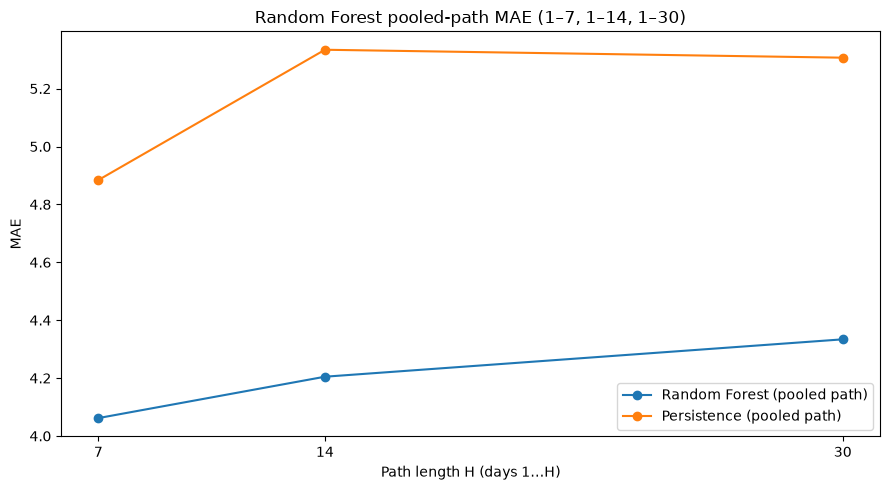

In [58]:
# ============================================================
# 17. MAE ACROSS FORECAST HORIZONS
# Changed: pooled path H in {7, 14, 30}, not day-h-only.
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    path_results_df["Horizon_Days"],
    path_results_df["MAE"],
    marker="o",
    label="Random Forest (pooled path)",
)
plt.plot(
    path_results_df["Horizon_Days"],
    path_results_df["Persistence_MAE"],
    marker="o",
    label="Persistence (pooled path)",
)

plt.xlabel("Path length H (days 1…H)")
plt.ylabel("MAE")
plt.title("Random Forest pooled-path MAE (1–7, 1–14, 1–30)")
plt.xticks(PATH_HORIZONS)
plt.legend()
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "rf_mae_across_horizons.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


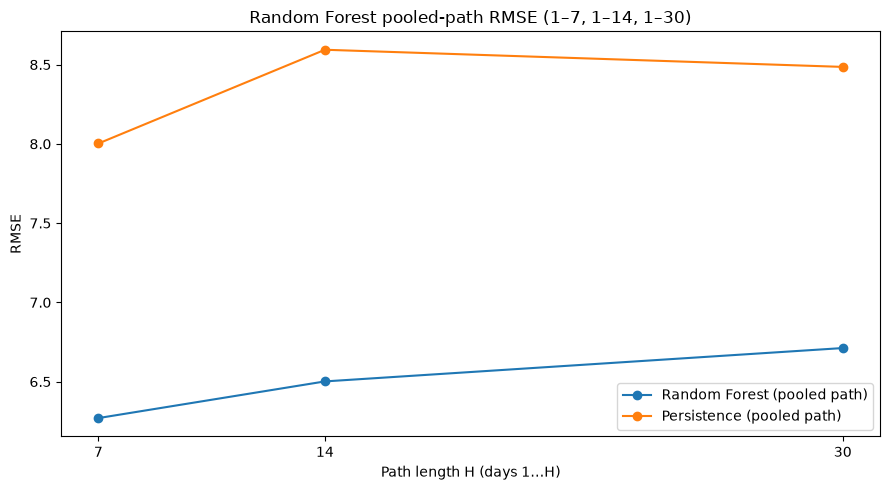

In [59]:
# ============================================================
# 18. RMSE ACROSS FORECAST HORIZONS
# Changed: pooled path H in {7, 14, 30}, not day-h-only.
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    path_results_df["Horizon_Days"],
    path_results_df["RMSE"],
    marker="o",
    label="Random Forest (pooled path)",
)
plt.plot(
    path_results_df["Horizon_Days"],
    path_results_df["Persistence_RMSE"],
    marker="o",
    label="Persistence (pooled path)",
)

plt.xlabel("Path length H (days 1…H)")
plt.ylabel("RMSE")
plt.title("Random Forest pooled-path RMSE (1–7, 1–14, 1–30)")
plt.xticks(PATH_HORIZONS)
plt.legend()
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "rf_rmse_across_horizons.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


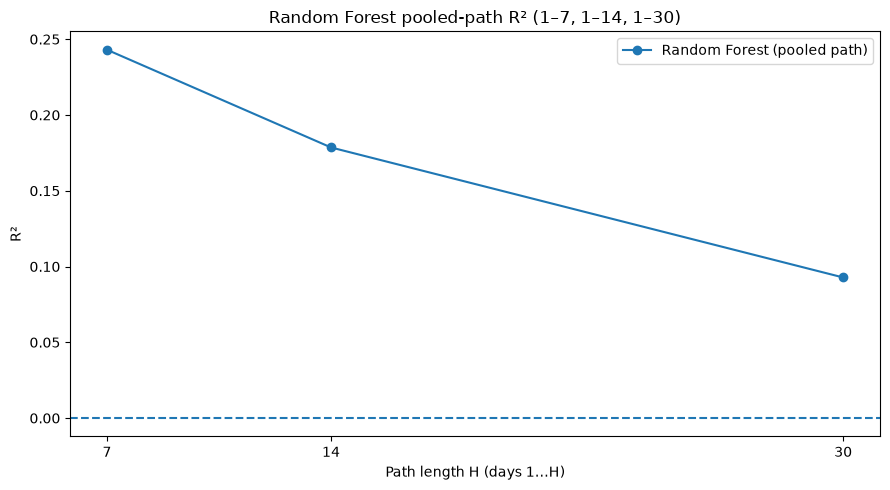

In [60]:
# ============================================================
# 19. R² ACROSS FORECAST HORIZONS
# Changed: pooled path H in {7, 14, 30}, not day-h-only.
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    path_results_df["Horizon_Days"],
    path_results_df["R2"],
    marker="o",
    label="Random Forest (pooled path)",
)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Path length H (days 1…H)")
plt.ylabel("R²")
plt.title("Random Forest pooled-path R² (1–7, 1–14, 1–30)")
plt.xticks(PATH_HORIZONS)
plt.legend()
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "rf_r2_across_horizons.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## Forecast trajectory and residual diagnostics

**Changed.** The time-series and residual plots now use the pooled path for *H* ∈ {7, 14, 30}.

The line plot averages actual and predicted PM₂.₅ over leads 1…*H* at each origin (same device as the neural notebooks). The residual scatter uses every stacked path point, matching the pooled MAE.

Residuals are \(e_i = y_i - \hat{y}_i\) on those stacked days.


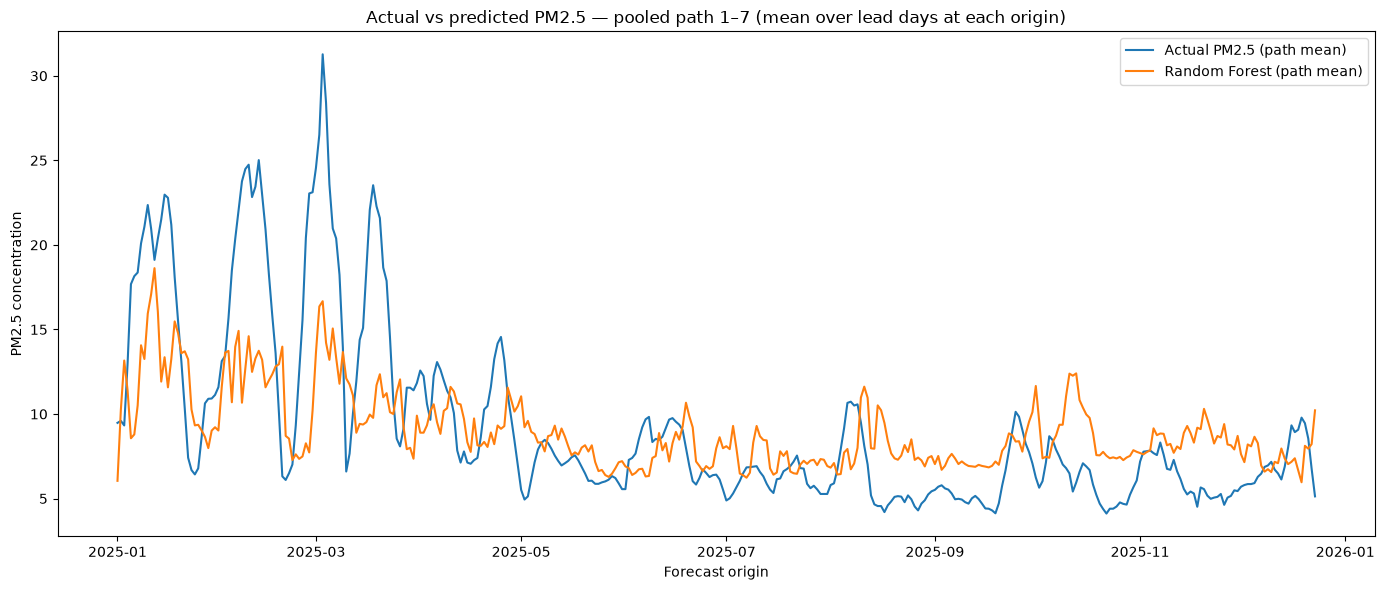

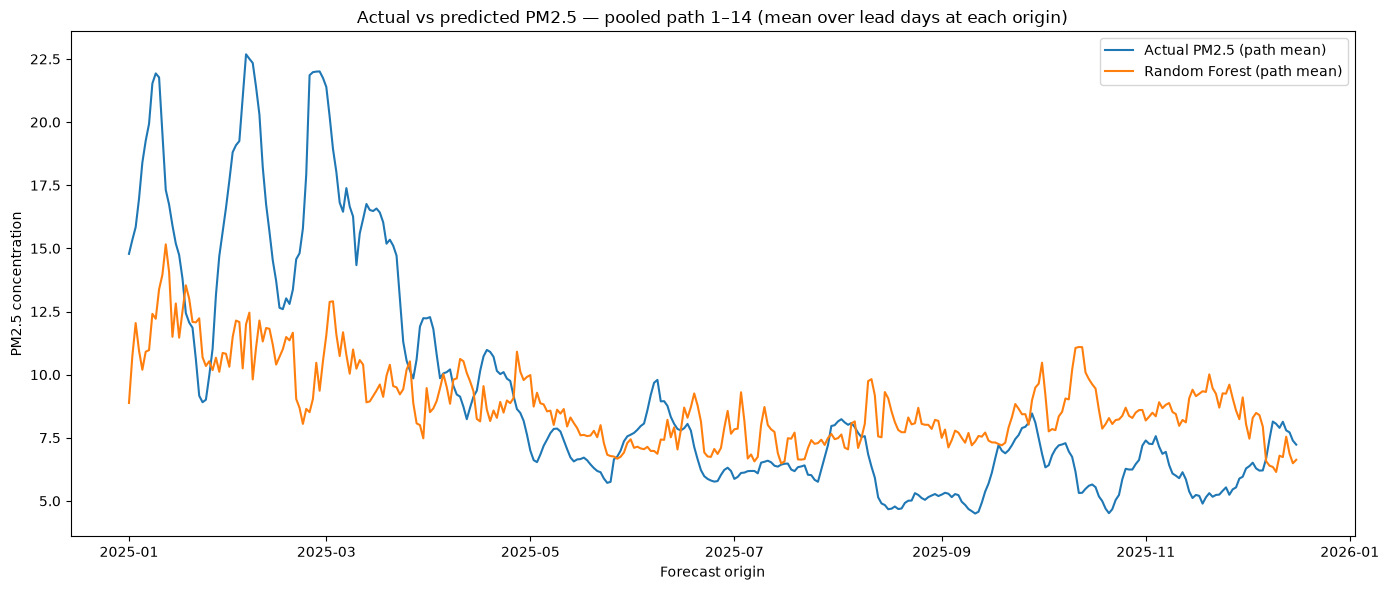

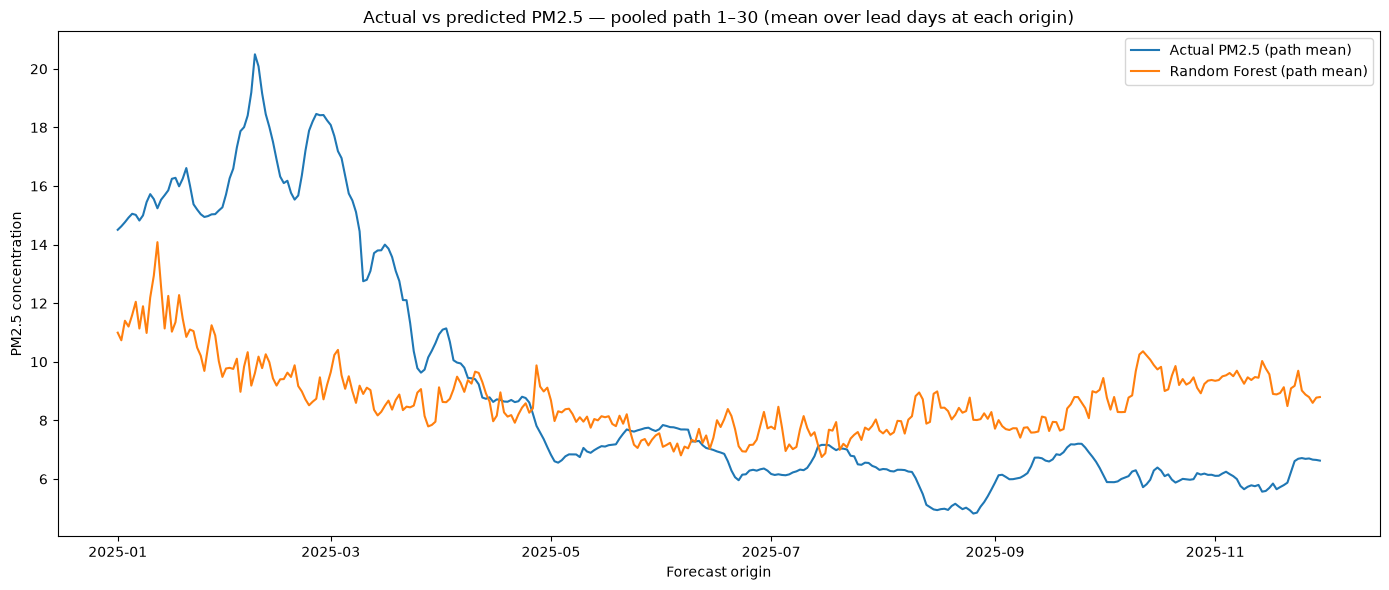

In [61]:
# ============================================================
# 20. ACTUAL VS PREDICTED PLOTS FOR POOLED PATHS
# Changed: H in {7, 14, 30}; mean over leads 1…H at each origin
# (matches neural actual-vs-predicted series). Was one panel per lead.
# ============================================================

for H in PATH_HORIZONS:
    path_df = stack_pooled_path(prediction_data, H)
    origin_mean = (
        path_df.groupby("Forecast_Origin", sort=True)[
            ["Actual_PM25", "Predicted_PM25"]
        ].mean()
    )

    plt.figure(figsize=(14, 6))
    plt.plot(
        origin_mean.index,
        origin_mean["Actual_PM25"],
        label="Actual PM2.5 (path mean)",
    )
    plt.plot(
        origin_mean.index,
        origin_mean["Predicted_PM25"],
        label="Random Forest (path mean)",
    )
    plt.xlabel("Forecast origin")
    plt.ylabel("PM2.5 concentration")
    plt.title(
        f"Actual vs predicted PM2.5 — pooled path 1–{H} "
        f"(mean over lead days at each origin)"
    )
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        RESULTS_DIR / f"rf_actual_vs_predicted_path_{H}d.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


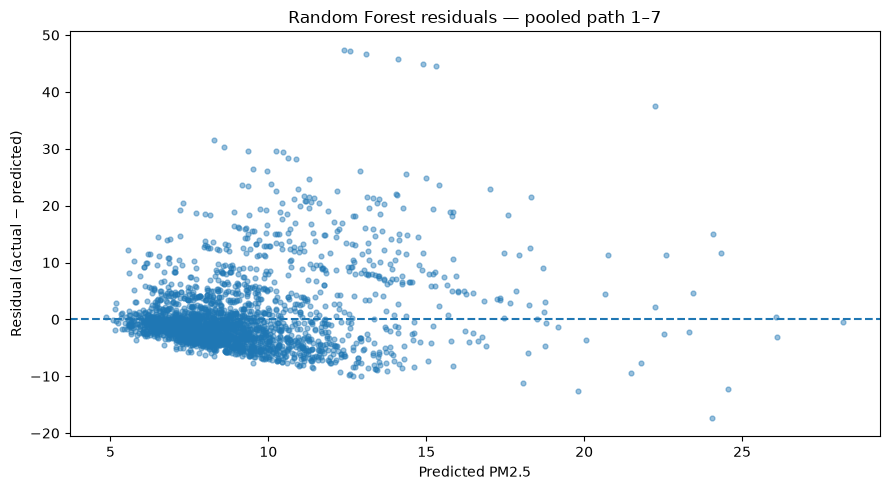

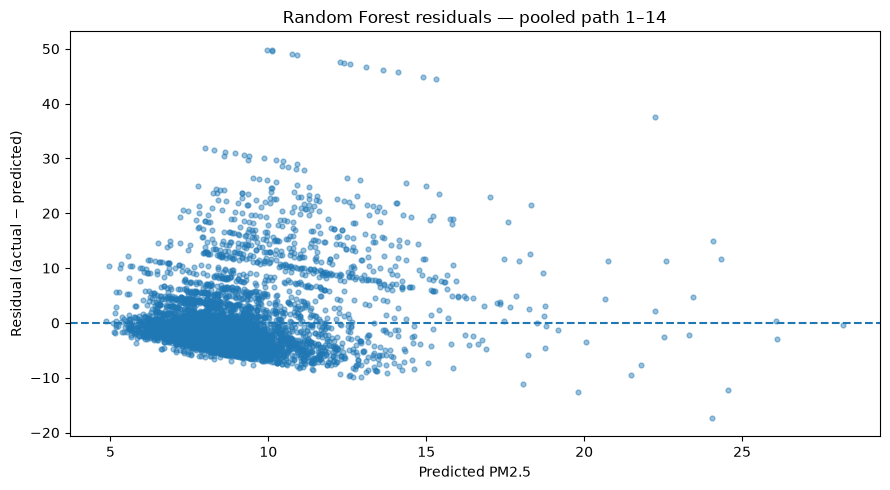

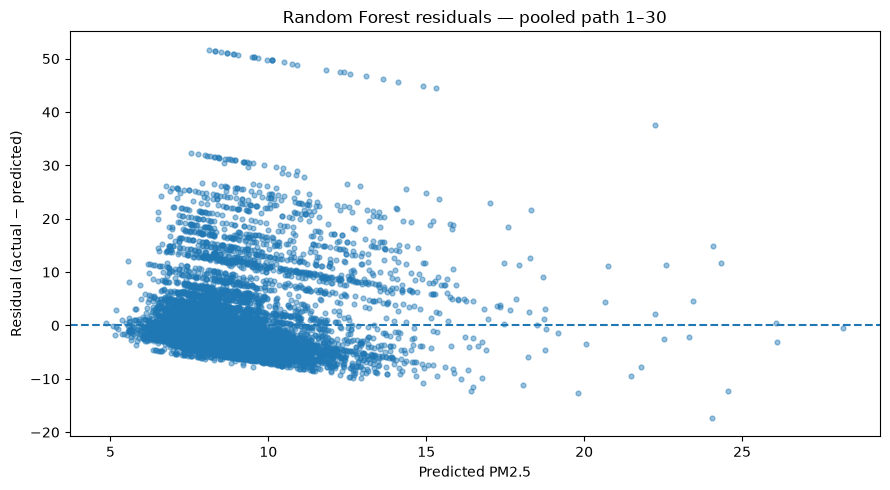

In [62]:
# ============================================================
# 21. RESIDUAL ANALYSIS FOR POOLED PATHS
# Changed: stacked leads 1…H, not day h only.
# ============================================================

for H in PATH_HORIZONS:
    path_df = stack_pooled_path(prediction_data, H)
    residual = path_df["Actual_PM25"] - path_df["Predicted_PM25"]

    plt.figure(figsize=(9, 5))
    plt.scatter(path_df["Predicted_PM25"], residual, alpha=0.45, s=12)
    plt.axhline(y=0, linestyle="--")
    plt.xlabel("Predicted PM2.5")
    plt.ylabel("Residual (actual − predicted)")
    plt.title(f"Random Forest residuals — pooled path 1–{H}")
    plt.tight_layout()
    plt.savefig(
        RESULTS_DIR / f"rf_residuals_path_{H}d.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


## Post-hoc interpretability using permutation importance

Permutation importance is used to quantify how strongly the fitted model depends on each predictor. For a given variable, its observed values are permuted while all other predictors are left unchanged; the resulting deterioration in predictive performance is then measured. Larger decreases in performance imply greater predictive reliance on that variable.

Importance is estimated separately for each horizon because the information supporting next-day forecasts may differ from that supporting multi-week forecasts. Short-horizon performance may depend more heavily on recent pollution dynamics, whereas longer-horizon performance may increasingly reflect seasonal or broader meteorological structure.

These importance values should be interpreted as **predictive associations within the fitted model**, not as estimates of causal influence. Because correlated variables can share or redistribute importance, emphasis should be placed on recurring patterns and physically plausible groups of predictors rather than on a single rank in isolation.

---

> **Needs rewrite.** This markdown still describes the original setup (direct models only at 1, 7, 14 and 30 days; the score is day *h* only). After the code change: a direct model is trained for every lead 1…30. The numbers that match CNN-LSTM / transformer / LSTM / GRU are **pooled over the full path** `[y_{t+1}, …, y_{t+H}]` for *H* in {7, 14, 30}, using test origins that have every lead of that path.


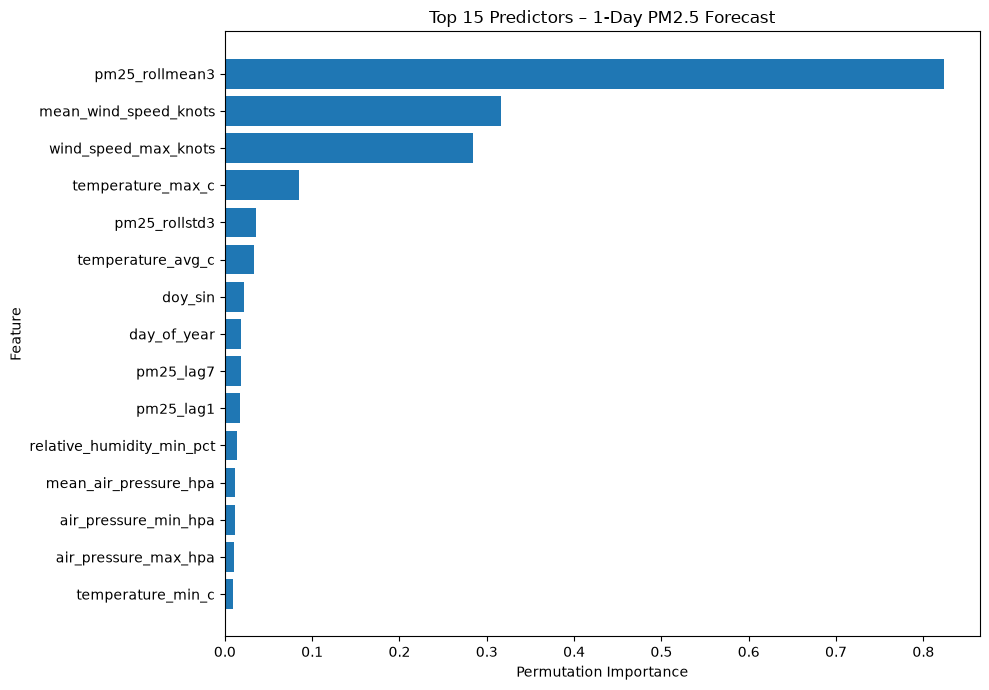

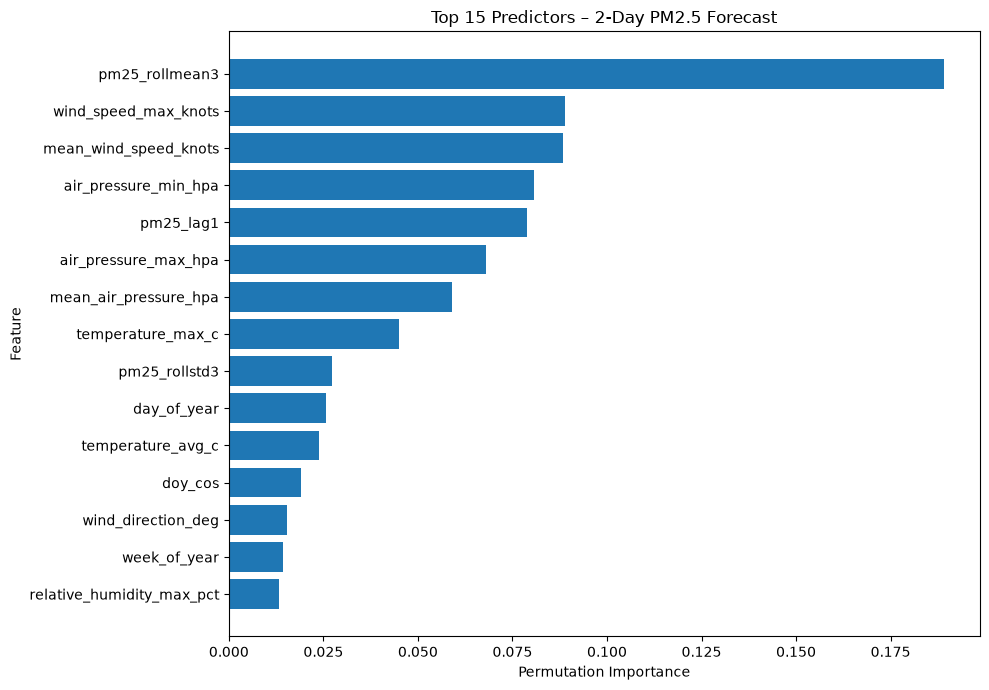

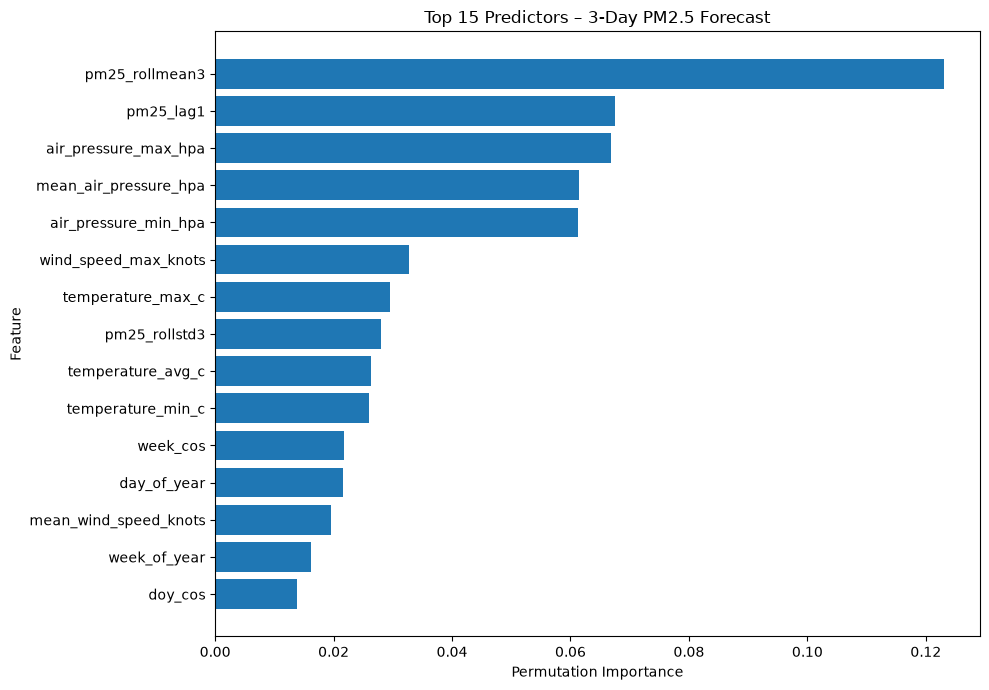

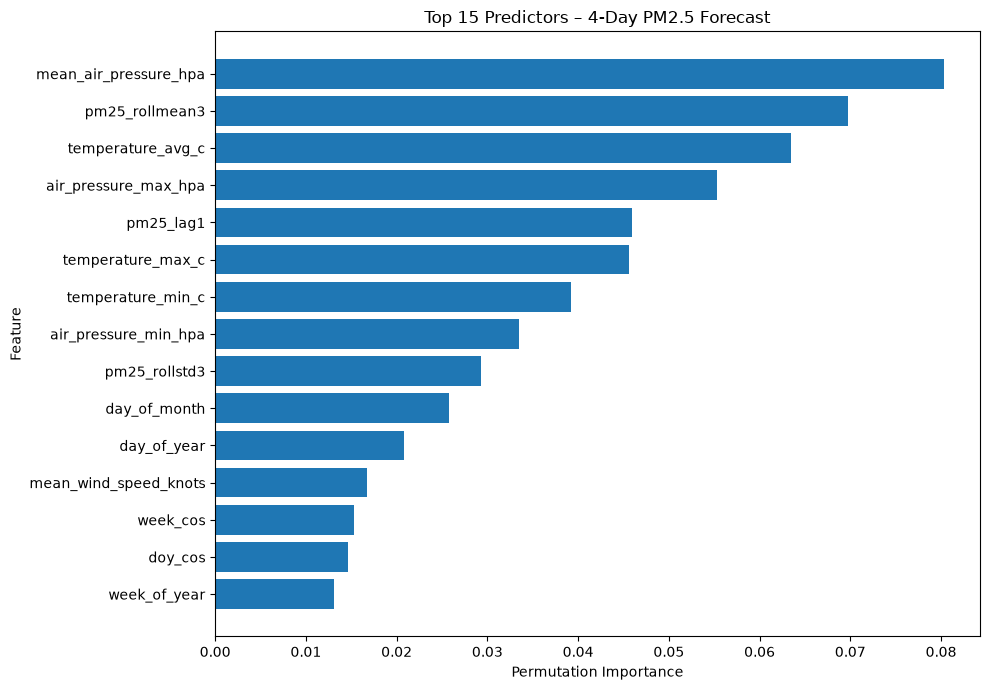

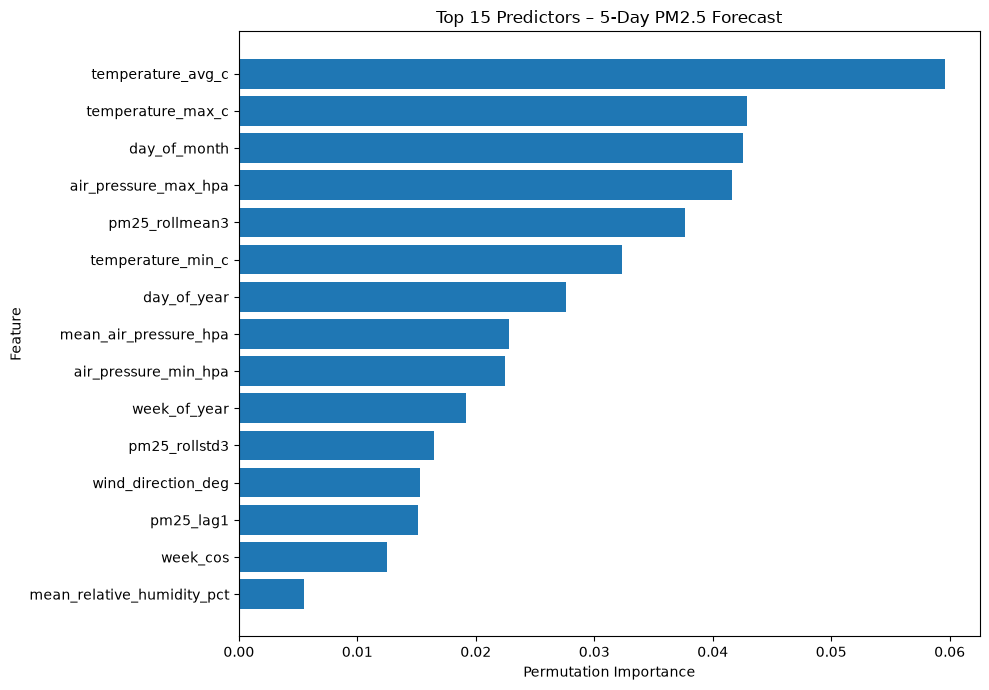

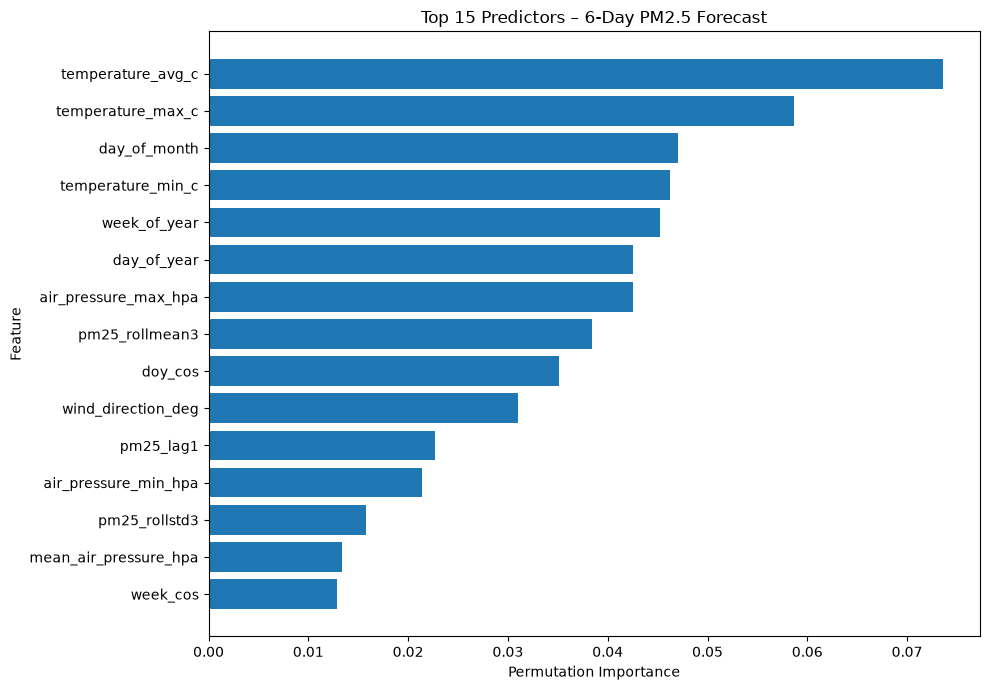

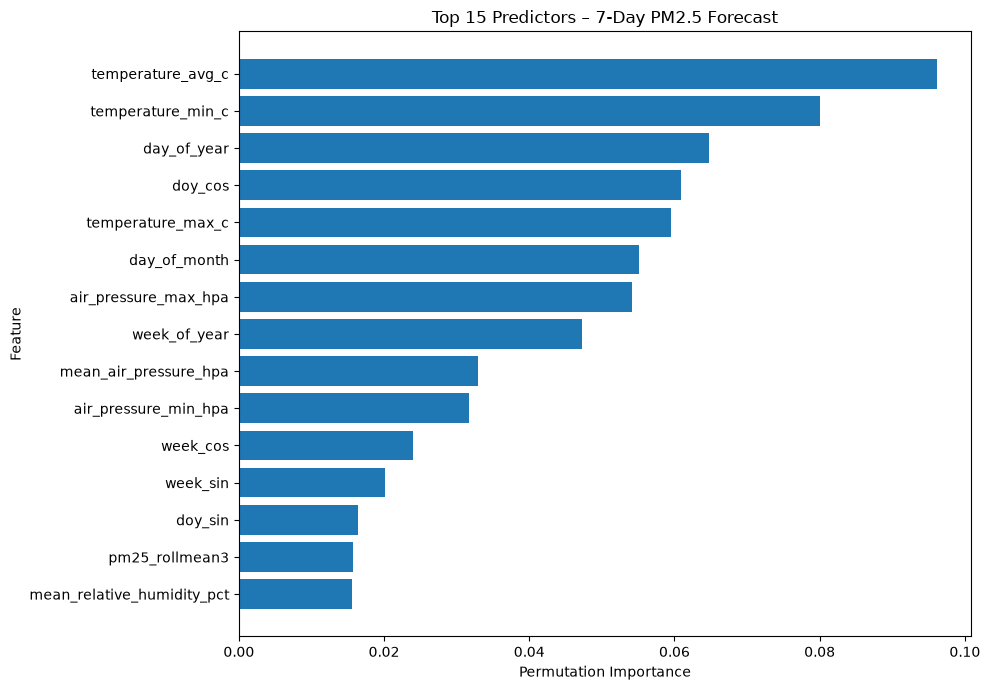

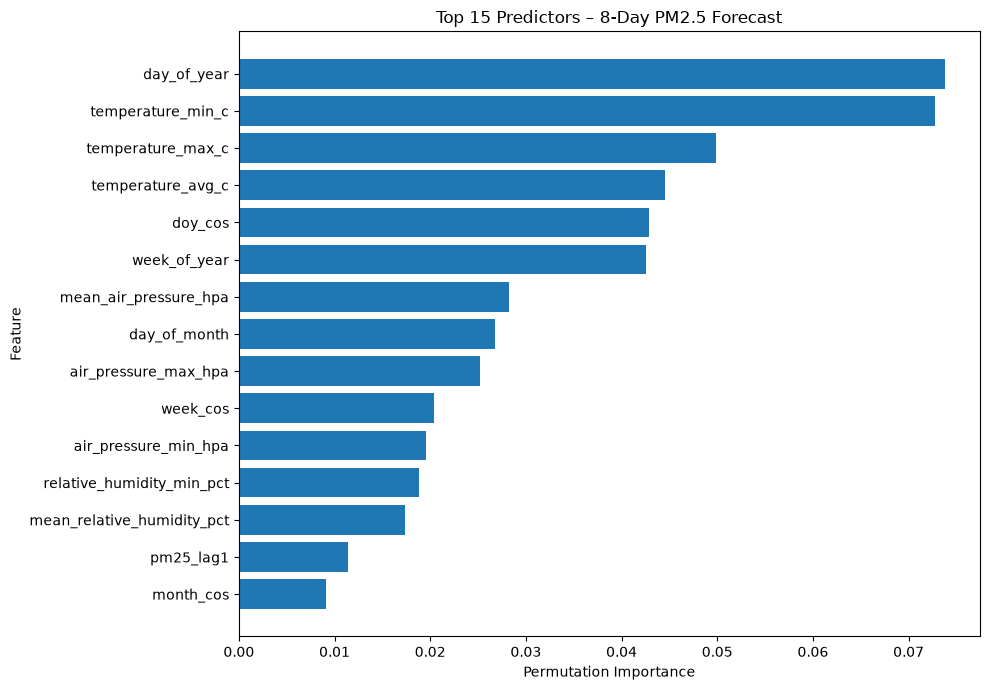

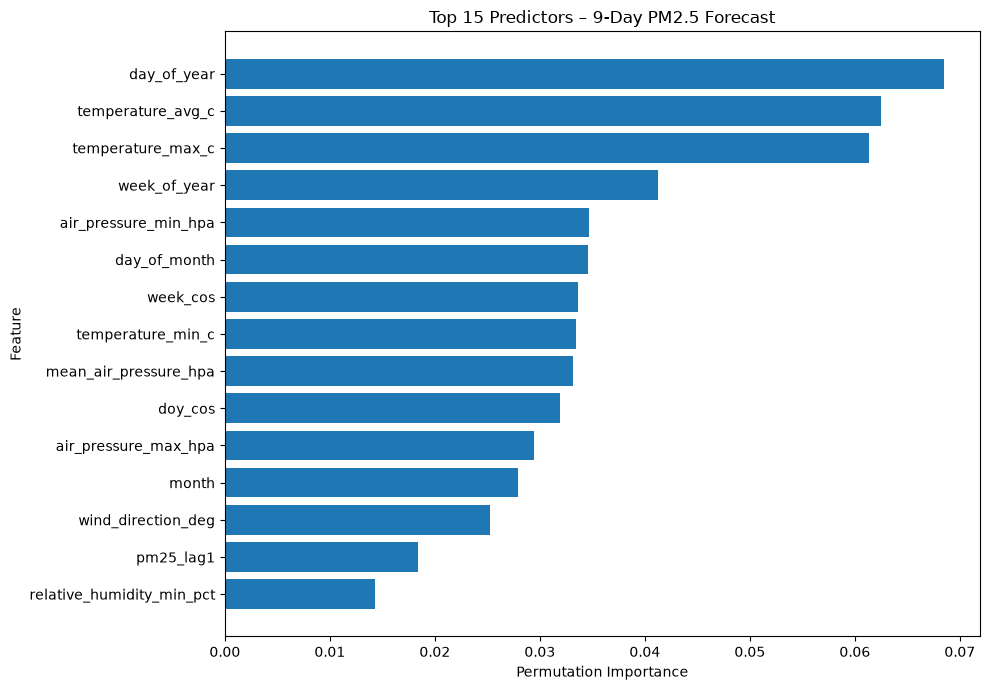

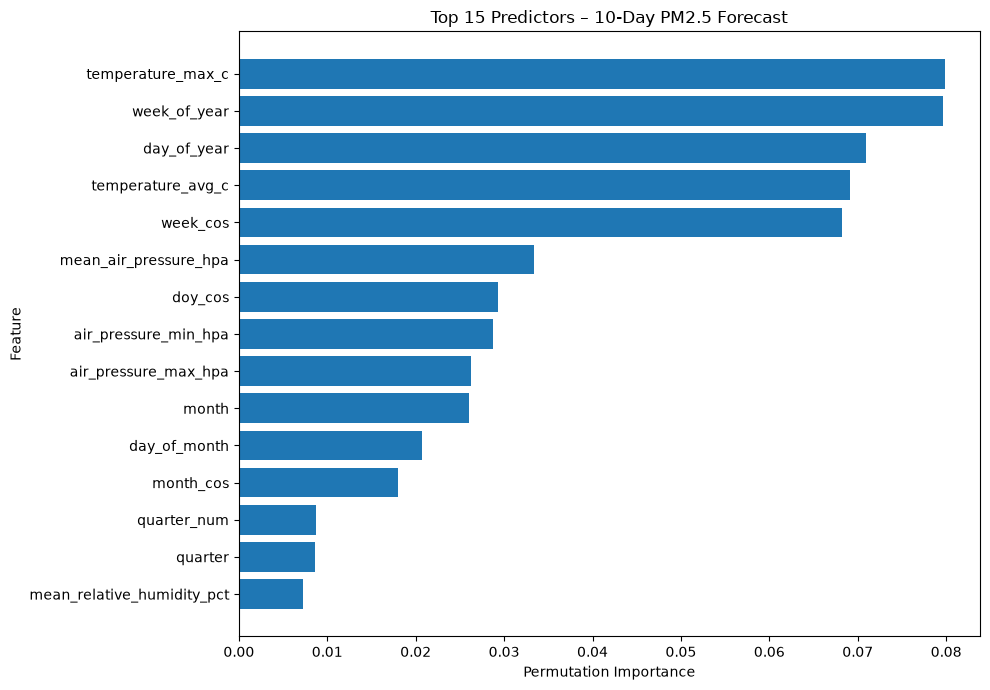

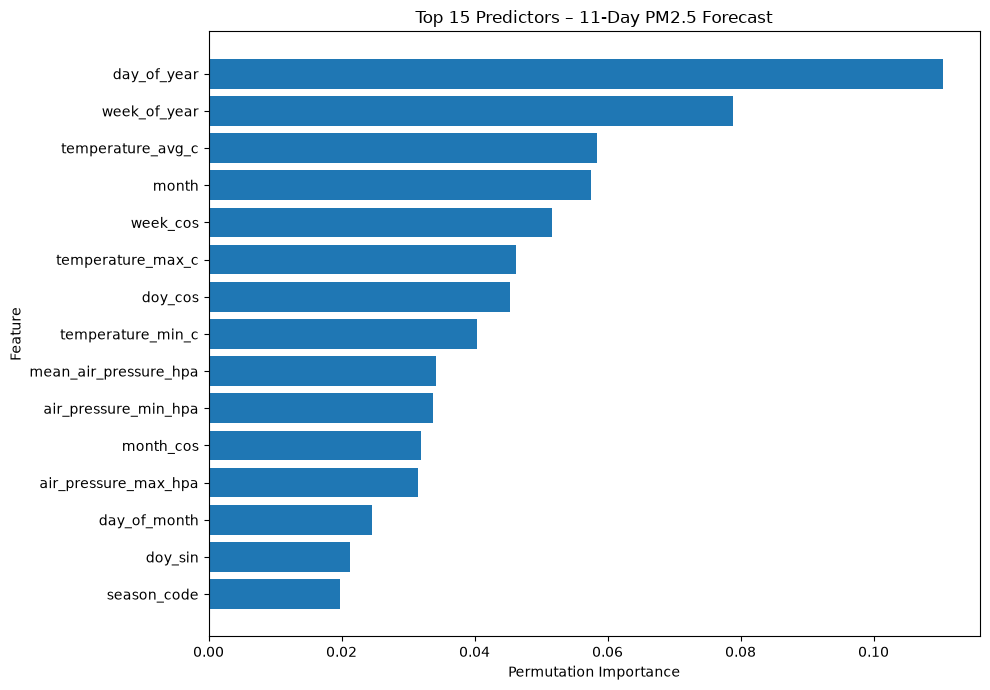

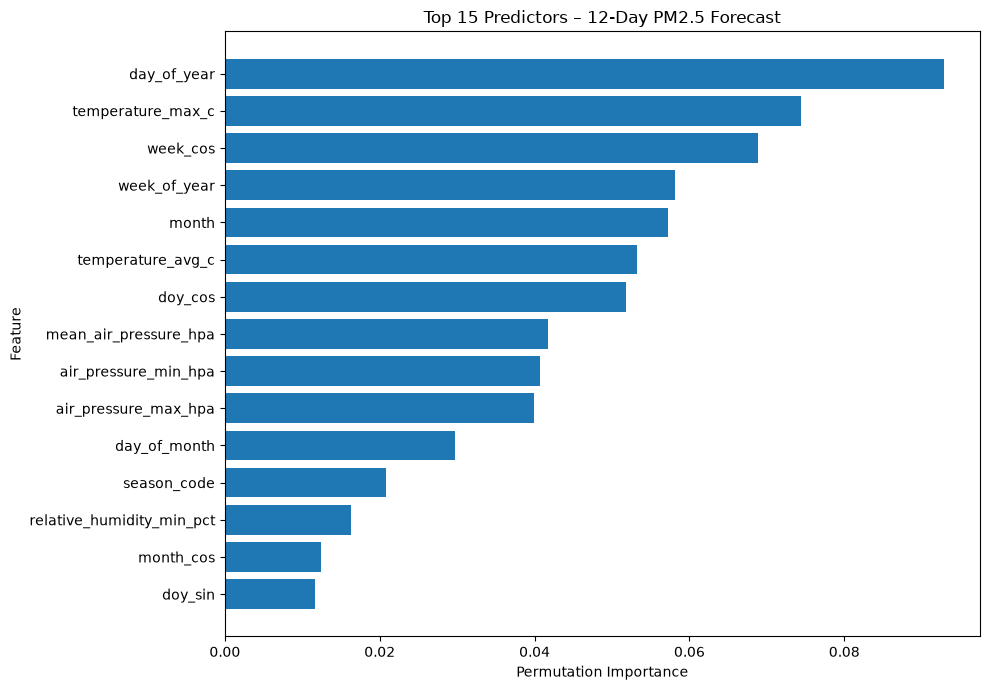

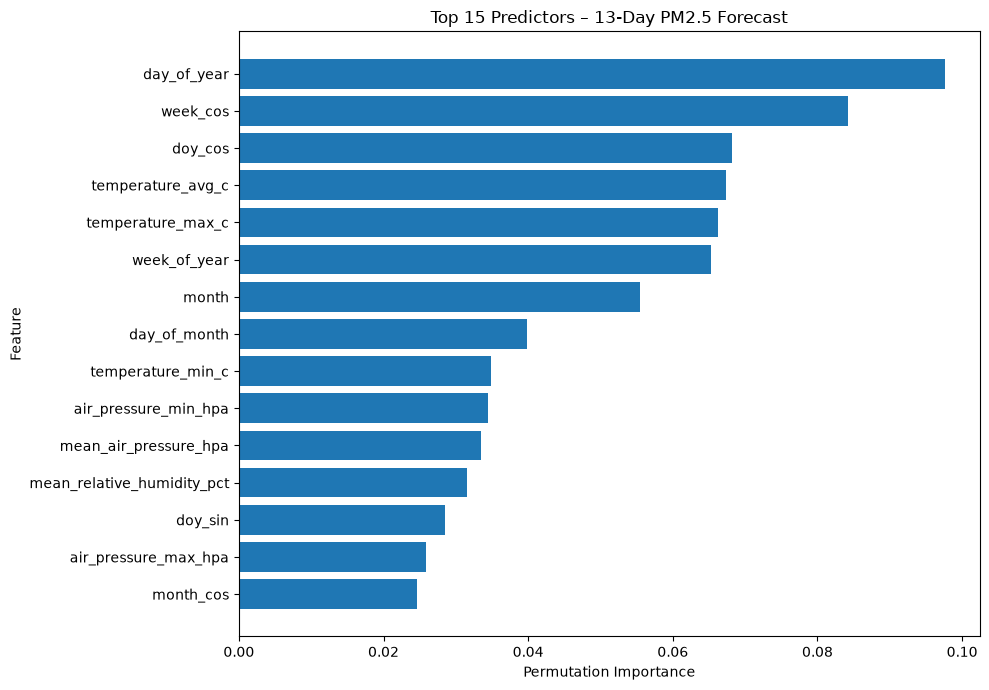

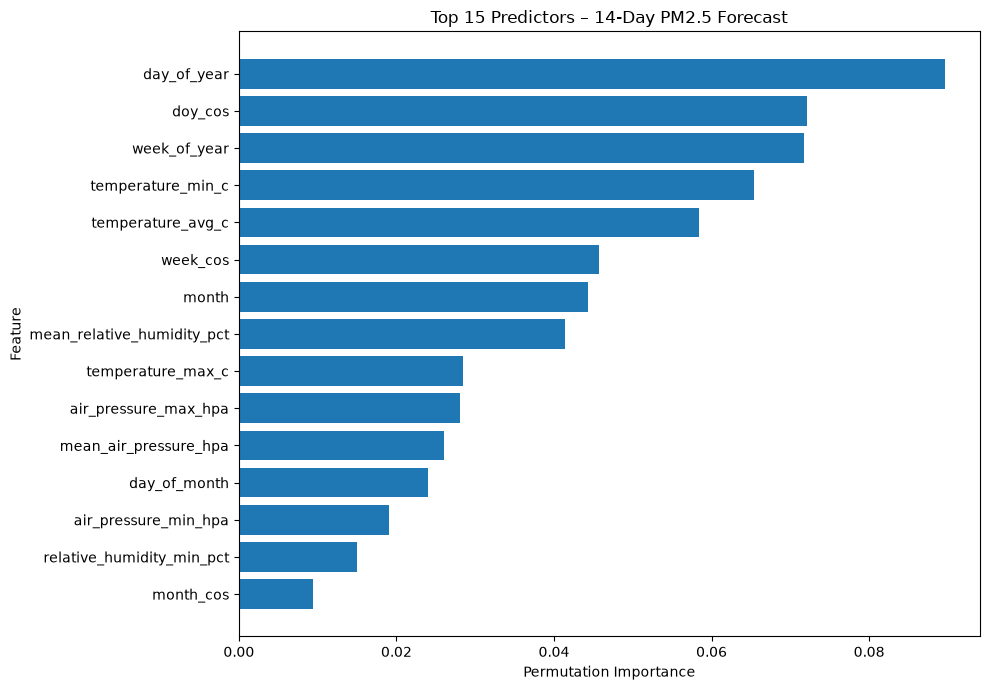

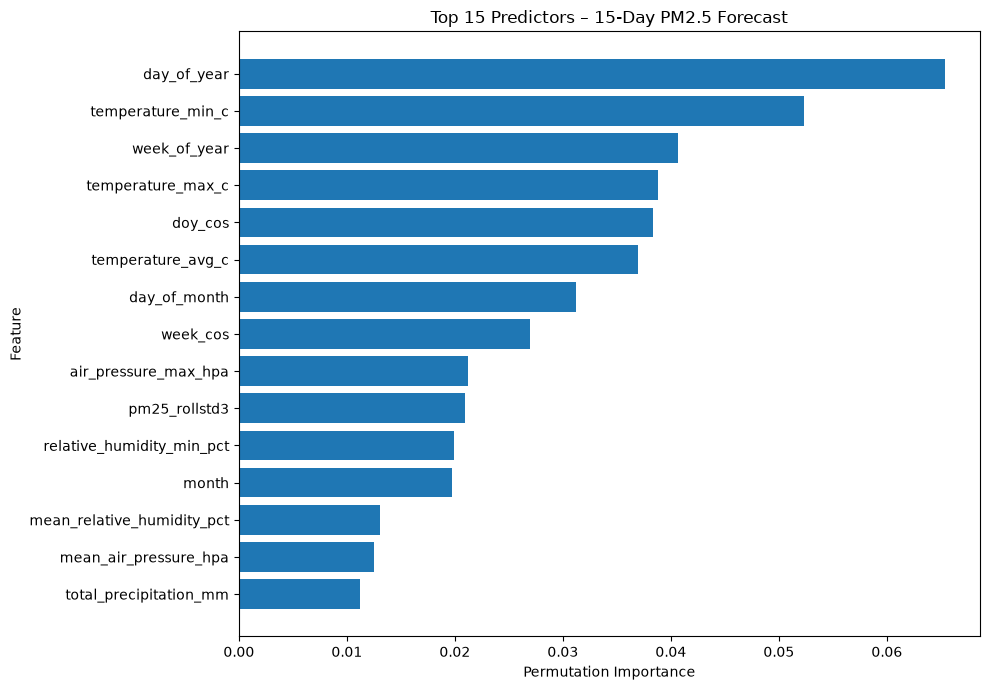

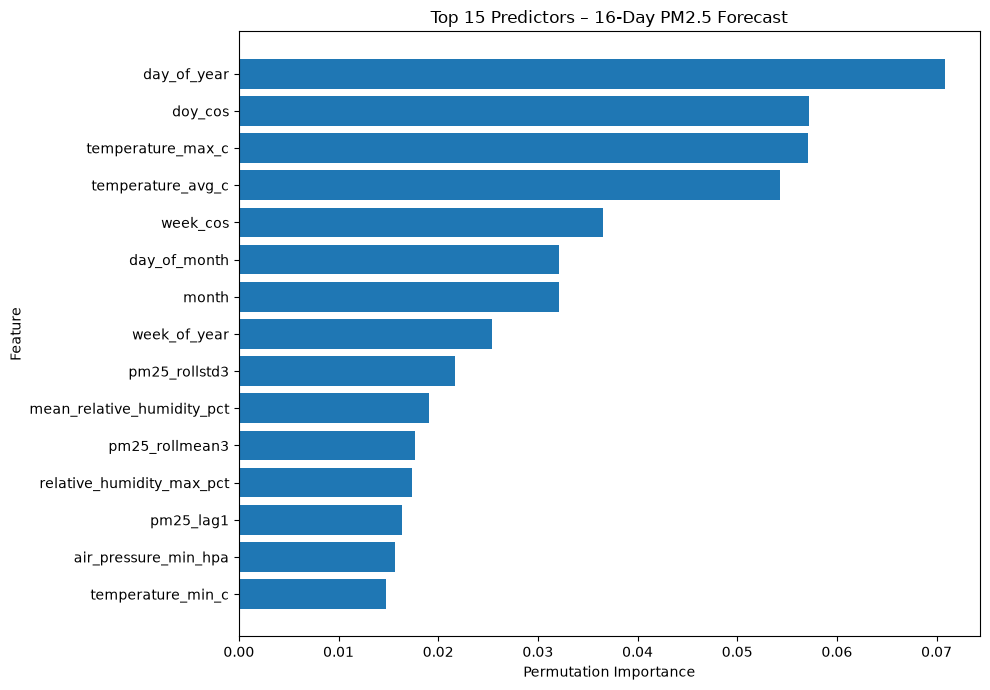

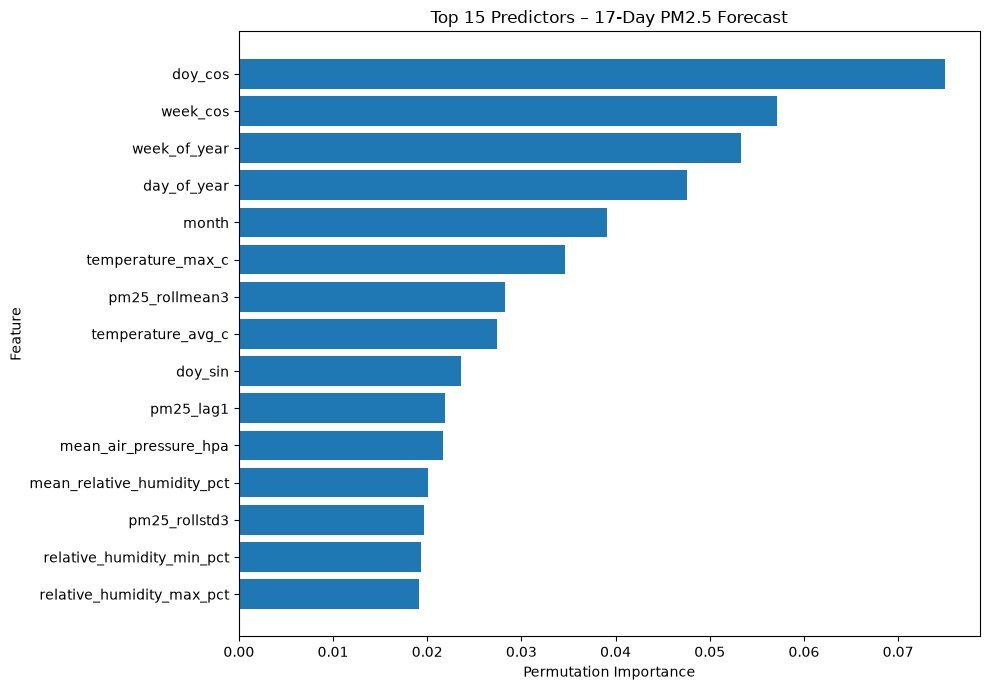

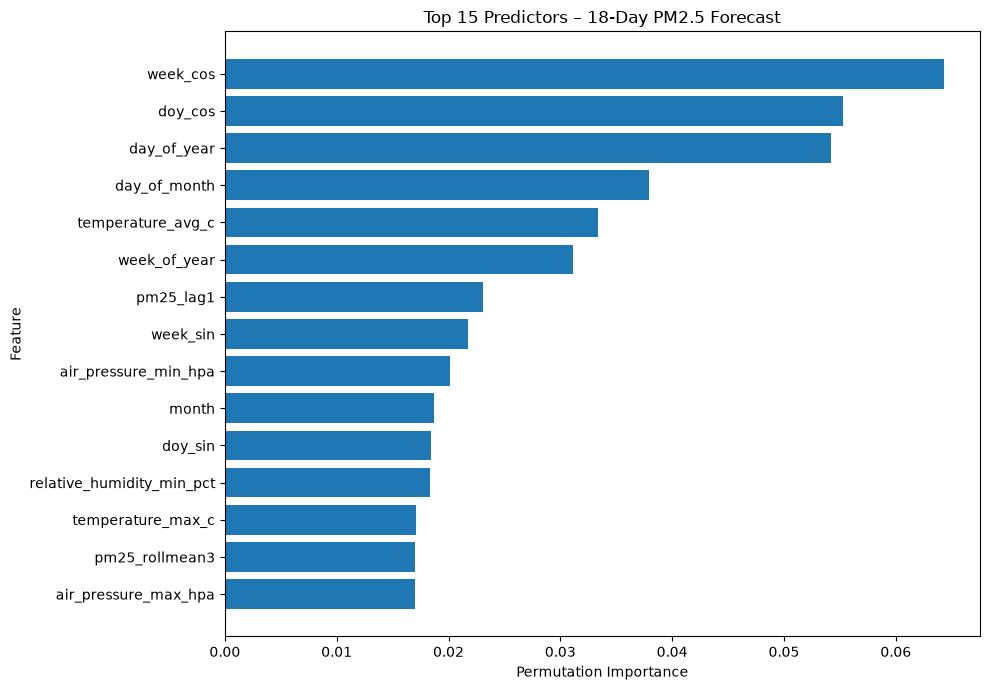

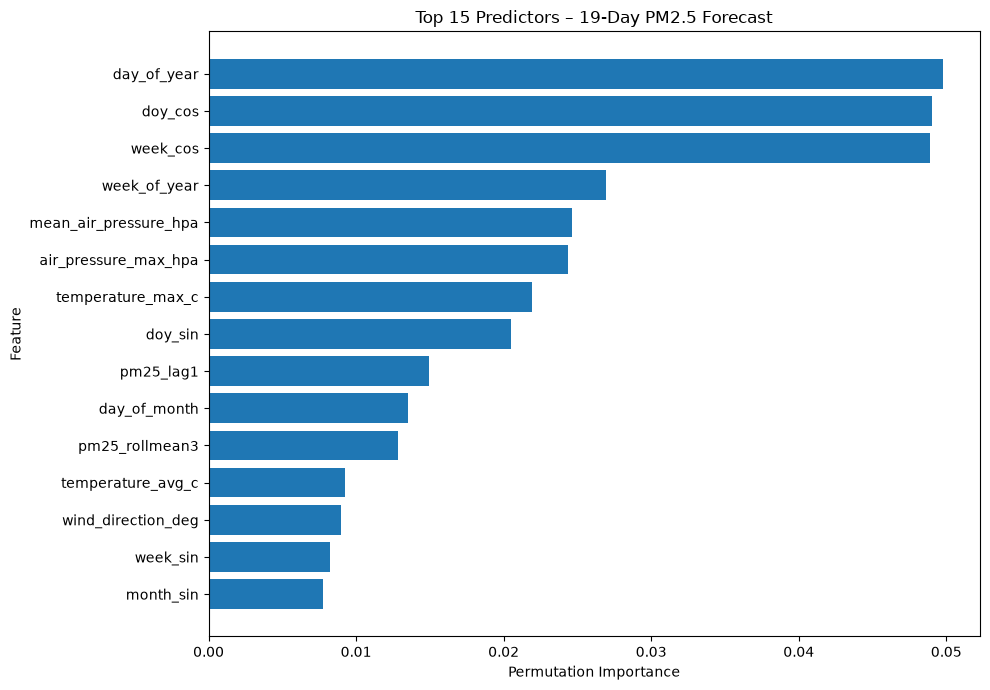

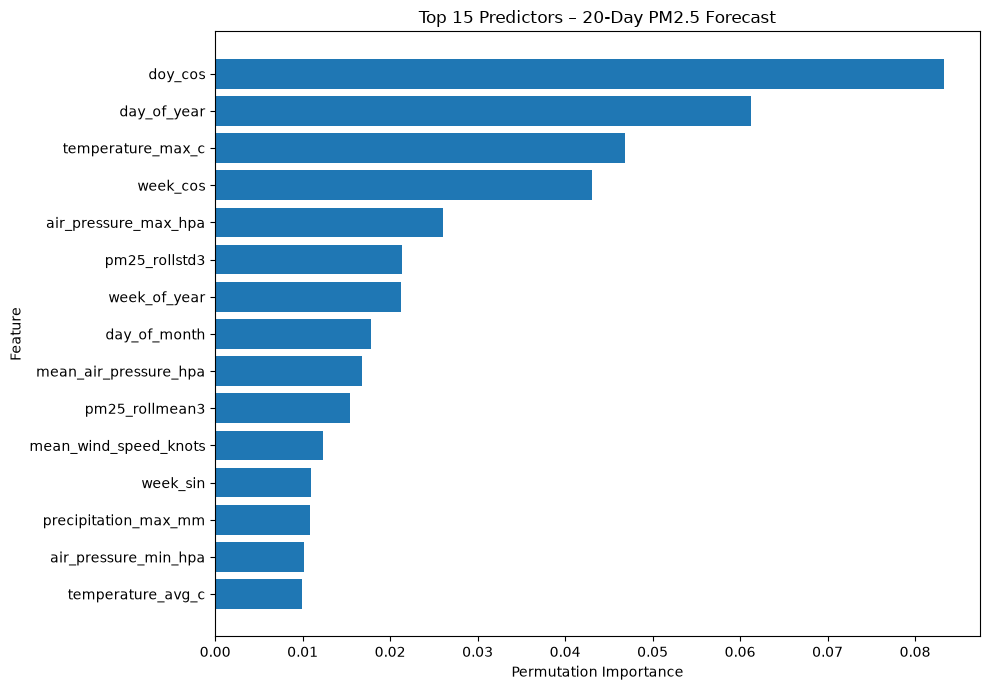

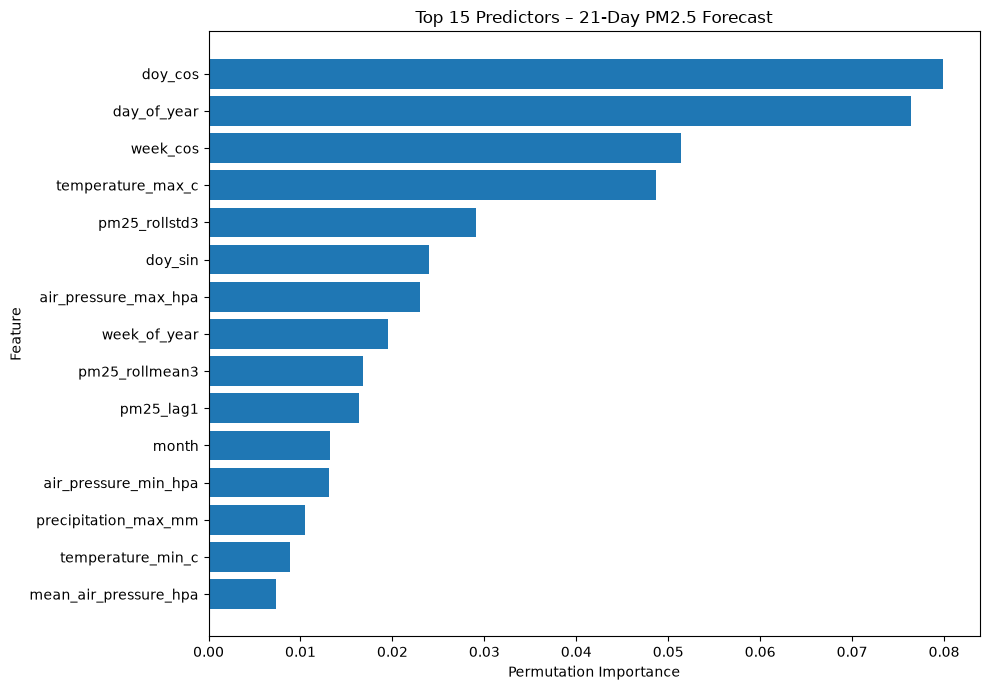

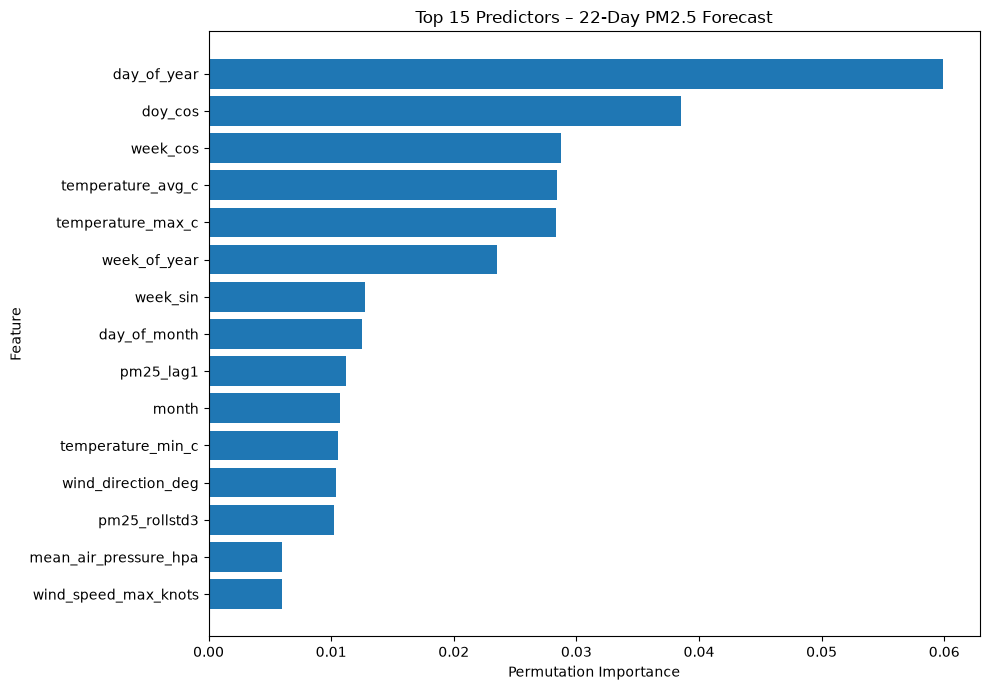

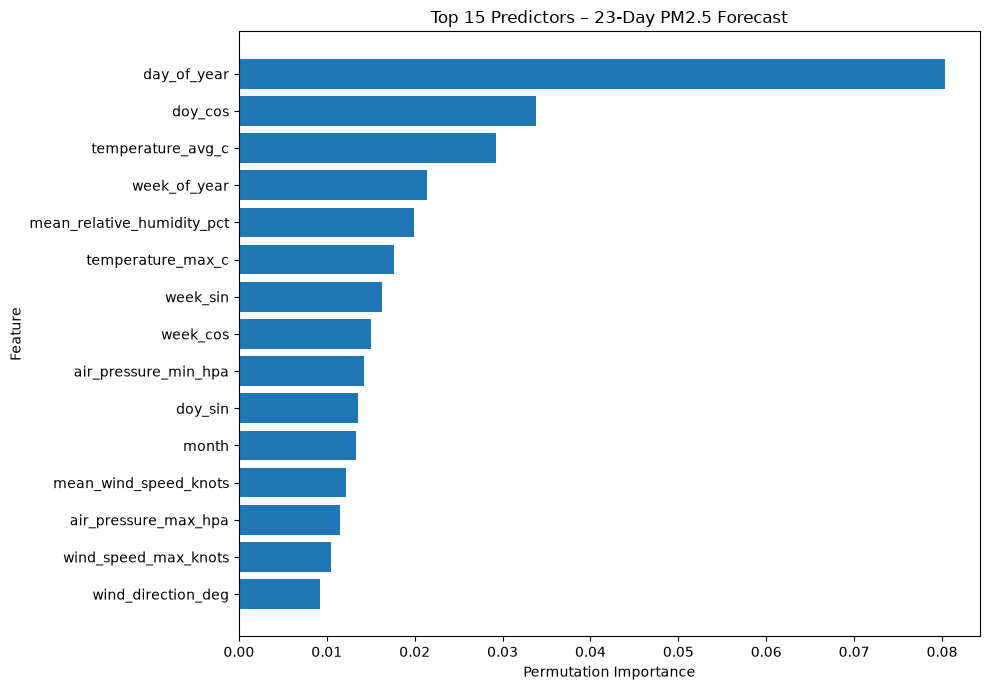

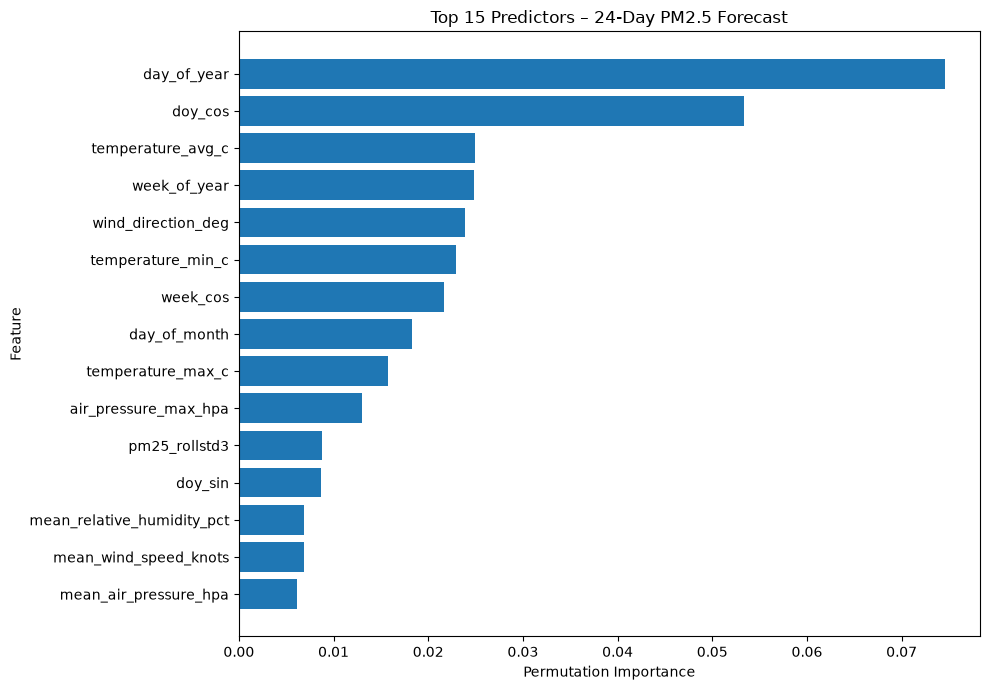

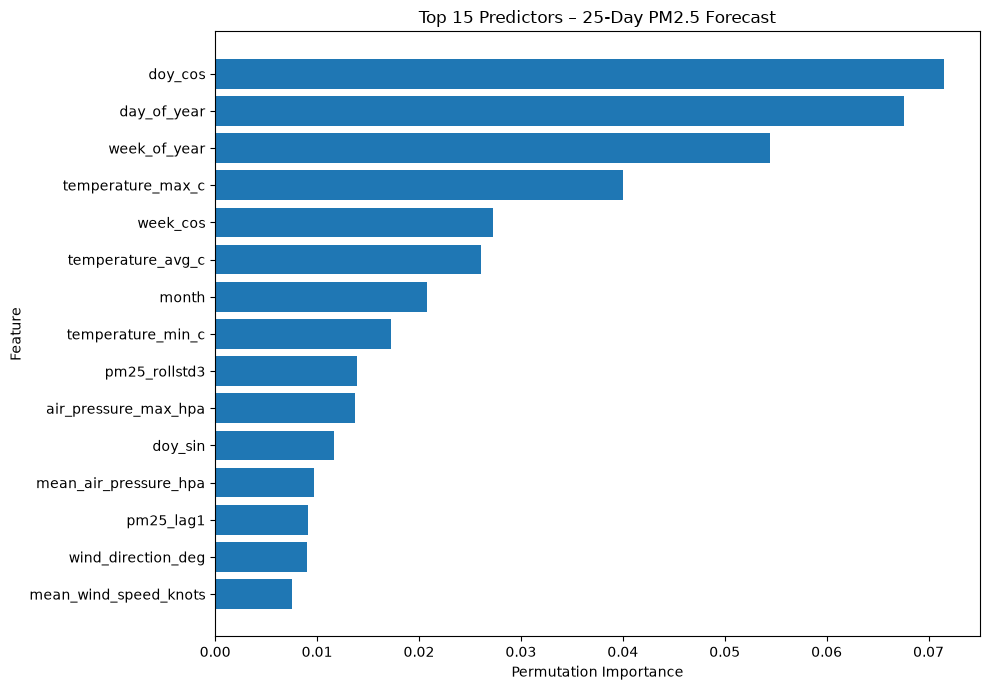

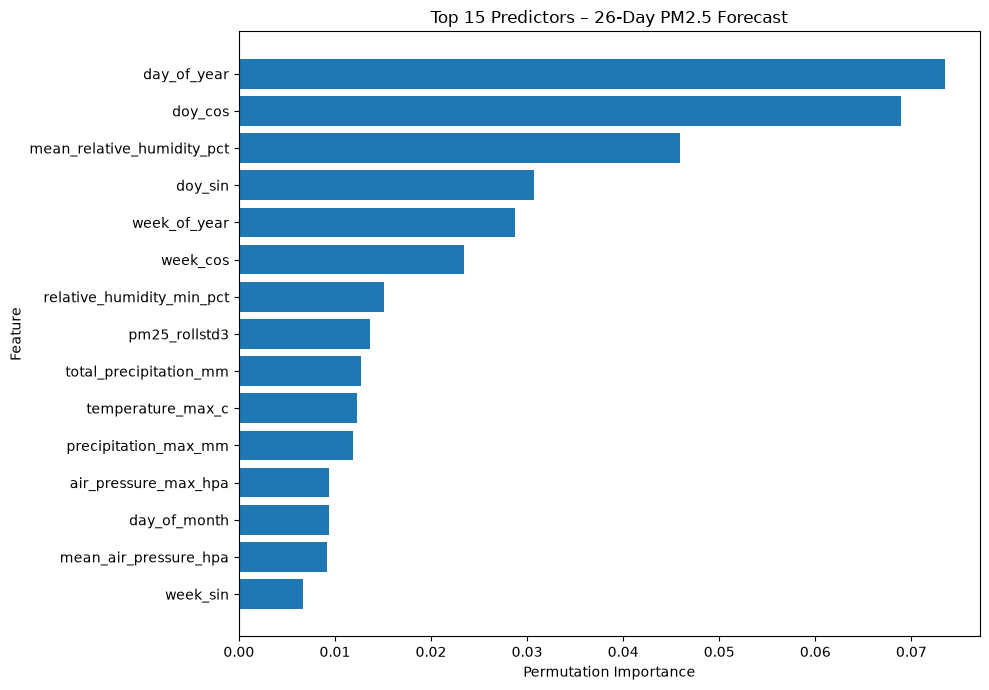

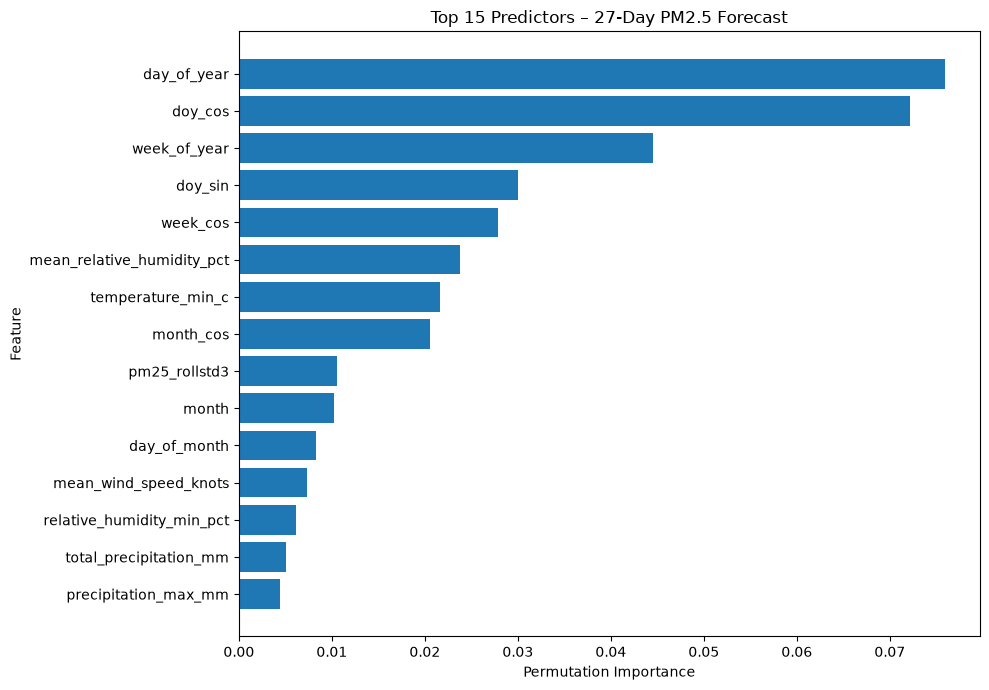

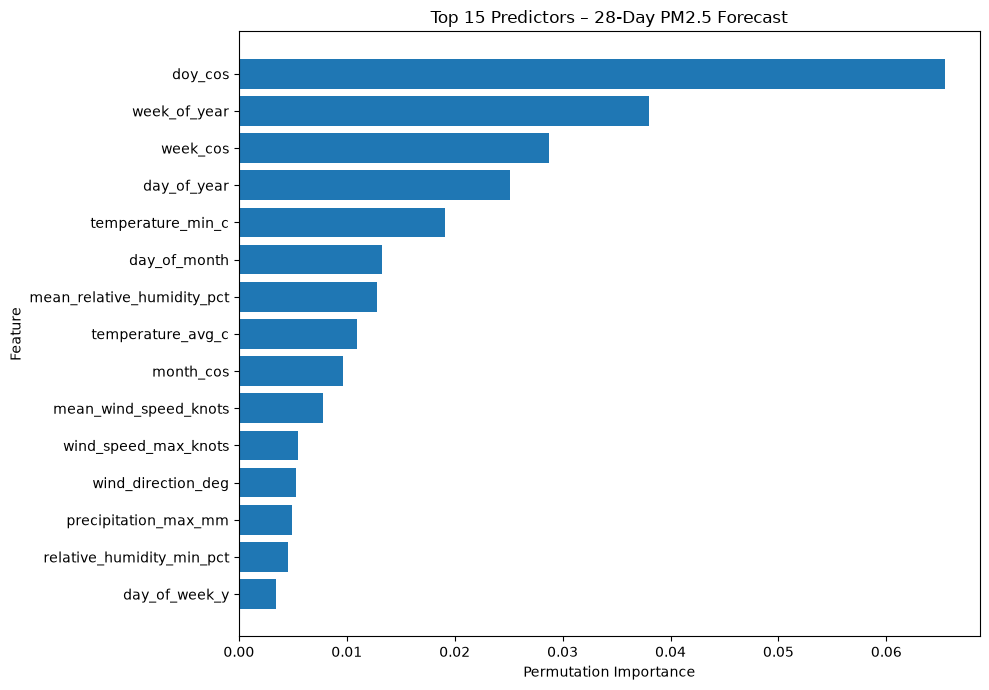

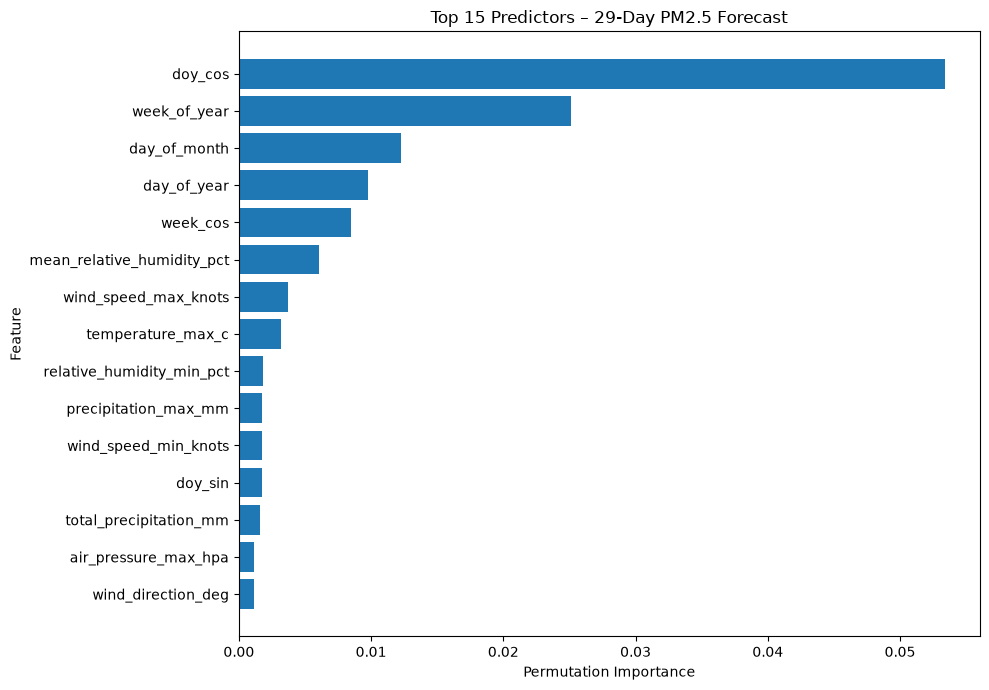

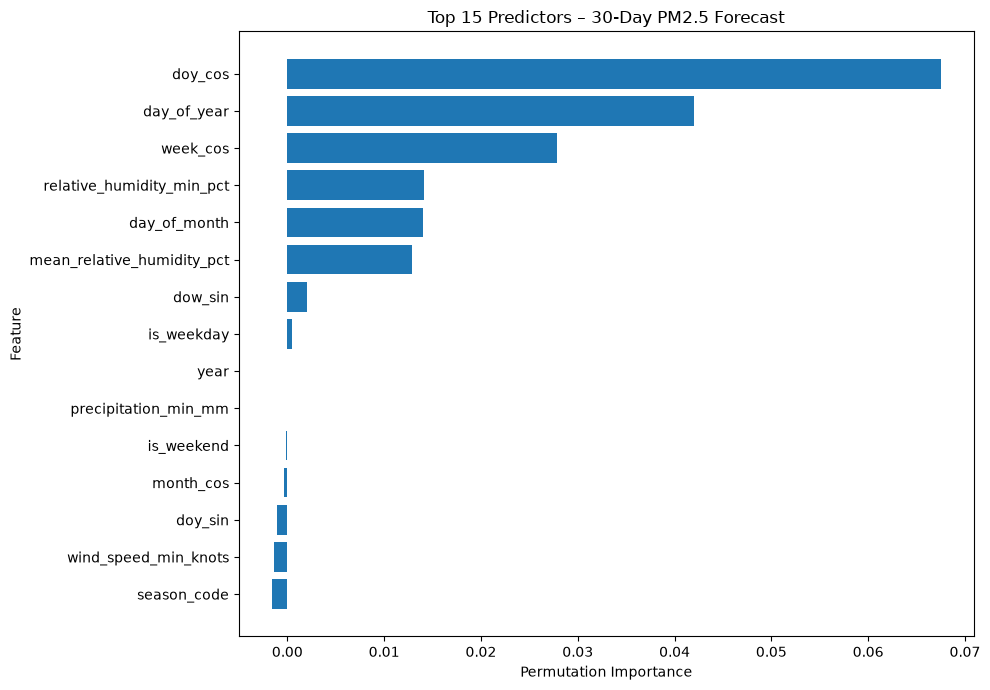

In [63]:
# Changed: left as per-lead plots. Permutation importance is defined
# on one direct model, not on a stacked 1…H path.
# ============================================================
# 22. PERMUTATION IMPORTANCE FOR EACH HORIZON
# ============================================================

for horizon in FORECAST_HORIZONS:

    importance_df = (
        permutation_importance_data[
            horizon
        ]
        .head(15)
        .sort_values(
            "Importance_Mean"
        )
    )


    plt.figure(
        figsize=(10, 7)
    )


    plt.barh(

        importance_df[
            "Feature"
        ],

        importance_df[
            "Importance_Mean"
        ]
    )


    plt.xlabel(
        "Permutation Importance"
    )

    plt.ylabel(
        "Feature"
    )


    plt.title(
        f"Top 15 Predictors "
        f"– {horizon}-Day PM2.5 Forecast"
    )


    plt.tight_layout()


    plt.savefig(

        RESULTS_DIR
        /
        f"rf_permutation_importance_{horizon}d.png",

        dpi=300,

        bbox_inches="tight"
    )


    plt.show()


### Cross-horizon interpretation

The most informative feature-importance analysis is not simply the top-ranked predictor at one horizon, but whether the dominant information source changes as $h$ increases. A transition from recent PM$_{2.5}$ features toward seasonal and meteorological variables would suggest that the model moves from exploiting short-memory pollution dynamics to broader climatological structure at longer lead times. Any such conclusion should be based on the executed importance results and should be reported as an empirical pattern rather than a causal claim.

---

> **Needs rewrite.** This markdown still describes the original setup (direct models only at 1, 7, 14 and 30 days; the score is day *h* only). After the code change: a direct model is trained for every lead 1…30. The numbers that match CNN-LSTM / transformer / LSTM / GRU are **pooled over the full path** `[y_{t+1}, …, y_{t+H}]` for *H* in {7, 14, 30}, using test origins that have every lead of that path.


## Reproducibility and model artefacts

For each forecast horizon, the workflow stores the fitted estimator, test-set predictions, conventional Random Forest feature importance, permutation importance, and summary performance metrics. Retaining these artefacts supports reproducibility, model comparison, and subsequent error analysis without requiring the complete tuning procedure to be repeated.

The final results table should be used as the numerical source for any cross-model comparison. When comparing Random Forest with XGBoost or neural forecasting models, the comparison is valid only when models use the same target dates, forecast-horizon definition, holdout period, and metric conventions.

---

> **Needs rewrite.** This markdown still describes the original setup (direct models only at 1, 7, 14 and 30 days; the score is day *h* only). After the code change: a direct model is trained for every lead 1…30. The numbers that match CNN-LSTM / transformer / LSTM / GRU are **pooled over the full path** `[y_{t+1}, …, y_{t+H}]` for *H* in {7, 14, 30}, using test origins that have every lead of that path.


In [64]:
# ============================================================
# 23. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("RANDOM FOREST MODELLING COMPLETED")
print("=" * 80)


print(
    "\nSaved models:"
)

for horizon in FORECAST_HORIZONS:

    print(
        MODEL_DIR
        /
        f"random_forest_{horizon}d.joblib"
    )


print(
    "\nResults directory:",
    RESULTS_DIR.resolve()
)


print(
    "\nFinal performance:"
)


display(

    results_df[
        [
            "Horizon_Days",
            "CV_MAE",
            "MAE",
            "MSE",
            "RMSE",
            "R2",
            "MAPE",
            "MBE",
            "Persistence_MAE",
            "Persistence_MSE",
            "Persistence_RMSE",
            "Persistence_R2",
            "Persistence_MAPE",
            "Persistence_MBE",
            "MAE_Improvement_Percent",
            "RMSE_Improvement_Percent"
        ]
    ].round(4)
)



RANDOM FOREST MODELLING COMPLETED

Saved models:
saved_con_rf/random_forest_1d.joblib
saved_con_rf/random_forest_2d.joblib
saved_con_rf/random_forest_3d.joblib
saved_con_rf/random_forest_4d.joblib
saved_con_rf/random_forest_5d.joblib
saved_con_rf/random_forest_6d.joblib
saved_con_rf/random_forest_7d.joblib
saved_con_rf/random_forest_8d.joblib
saved_con_rf/random_forest_9d.joblib
saved_con_rf/random_forest_10d.joblib
saved_con_rf/random_forest_11d.joblib
saved_con_rf/random_forest_12d.joblib
saved_con_rf/random_forest_13d.joblib
saved_con_rf/random_forest_14d.joblib
saved_con_rf/random_forest_15d.joblib
saved_con_rf/random_forest_16d.joblib
saved_con_rf/random_forest_17d.joblib
saved_con_rf/random_forest_18d.joblib
saved_con_rf/random_forest_19d.joblib
saved_con_rf/random_forest_20d.joblib
saved_con_rf/random_forest_21d.joblib
saved_con_rf/random_forest_22d.joblib
saved_con_rf/random_forest_23d.joblib
saved_con_rf/random_forest_24d.joblib
saved_con_rf/random_forest_25d.joblib
saved_co

,Horizon_Days,CV_MAE,MAE,MSE,RMSE,R2,MAPE,MBE,Persistence_MAE,Persistence_MSE,Persistence_RMSE,Persistence_R2,Persistence_MAPE,Persistence_MBE,MAE_Improvement_Percent,RMSE_Improvement_Percent
0,1,2.7928,3.1536,26.0302,5.1020,0.4939,41.3530,0.0642,3.1241,32.1905,5.6737,0.3742,37.6353,0.0003,-0.9447,10.0762
1,2,3.4240,3.8167,35.0774,5.9226,0.3196,49.7332,-0.0928,4.3659,55.1962,7.4294,-0.0706,52.3665,0.0083,12.5800,20.2815
2,3,3.6893,4.0959,38.9895,6.2442,0.2450,52.7360,-0.2005,4.7610,62.6027,7.9122,-0.2122,57.2006,0.0338,13.9707,21.0817
3,4,3.7720,4.2535,41.1898,6.4179,0.2038,54.7003,-0.1783,4.9981,64.0262,8.0016,-0.2376,62.6739,0.0606,14.8994,19.7923
4,5,3.8126,4.4104,44.0038,6.6335,0.1500,55.7433,-0.2628,5.4364,69.8881,8.3599,-0.3499,69.6439,0.0407,18.8723,20.6506
5,6,3.9011,4.4372,45.5021,6.7455,0.1236,56.0733,-0.2663,5.6239,80.0164,8.9452,-0.5412,70.6161,0.0539,21.1011,24.5905
6,7,3.9120,4.3806,44.4789,6.6692,0.1441,54.8548,-0.3842,5.7599,81.8272,9.0458,-0.5746,71.4185,0.0804,23.9479,26.2727
7,8,3.9017,4.4166,46.2635,6.8017,0.1117,54.7665,-0.4771,5.8210,82.4863,9.0822,-0.5838,72.3450,0.0537,24.1269,25.1092
8,9,4.0014,4.4234,46.2865,6.8034,0.1136,54.5433,-0.4929,5.8919,84.4717,9.1908,-0.6177,69.9102,0.0292,24.9239,25.9761
9,10,3.9596,4.4670,48.5260,6.9661,0.0729,53.8982,-0.6508,5.8879,86.9768,9.3261,-0.6616,68.6428,0.0318,24.1332,25.3061
